In [1]:
# ============================================================
# 1. НАСТРОЙКА ПУТЕЙ И ИМПОРТ МОДУЛЯ
# ============================================================


import sys
from pathlib import Path
import traceback
import re
from typing import List, Dict, Any, Optional, Union, Pattern, Tuple
import numpy as np
import scipy.signal
import pickle
from tqdm import tqdm
from datetime import datetime

# Добавляем путь к папке с нашим модулем (eeg_database_toolkit_alexey)
module_path = Path.cwd().parent / "eeg_toolkit"
if str(module_path) not in sys.path:
    sys.path.insert(0, str(module_path))

import eeg_database_toolkit as ADT
import eeg_database_filters as filters
import feature_extractors as extractors

# raw_data_root = Path(r"C:\Users\Admin\Desktop\EEG\all_marked_fresh_EEG_data_with_correct_indexes")
db_root = Path(r"C:\Users\Admin\Desktop\EEG\global_EEG_processed_DB_bipolar")
configs = filters.load_interval_configs()
depd_config = configs['depd_numeric']
sleep_config = configs['sleep_awake']

# Создание базового датасета скользящих окон

In [3]:
# """
# Скрипт для создания базового датасета скользящих окон из ЭЭГ записей с ДЭПД разметкой.
# Параллельная обработка записей.

# Количество потоков по дефолту 22. На ПК, где скрипт запускался первый рах, их 24. 2 оставлено системе
# """

# import sys
# from pathlib import Path
# import numpy as np
# import scipy.signal
# import pickle
# from tqdm import tqdm
# from datetime import datetime
# from typing import List, Dict, Tuple, Optional
# from joblib import Parallel, delayed


# # ============================================================
# # ПАРАМЕТРЫ
# # ============================================================

# LOWCUT = 1.0
# HIGHCUT = 35.0
# FILTER_ORDER = 4
# WINDOW_DUR = 1.0
# STEP_DUR = 0.1
# FS_TARGET = 200.0

# N_JOBS = 10 # 22

# # Пути
# db_root = Path(r"C:\Users\Admin\Desktop\EEG\global_EEG_processed_DB_bipolar")
# configs = filters.load_interval_configs()
# depd_config = configs['depd_numeric']
# sleep_config = configs['sleep_awake']

# # ============================================================
# # ФУНКЦИИ ОБРАБОТКИ
# # ============================================================

# def butter_bandpass_filter(data, fs, lowcut, highcut, order=4):
#     nyq = 0.5 * fs
#     b, a = scipy.signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
#     return scipy.signal.lfilter(b, a, data, axis=-1)

# def resample_to_target(data, sfreq_in, sfreq_out=FS_TARGET):
#     if abs(sfreq_in - sfreq_out) < 1e-9:
#         return data.astype(np.float32, copy=True)
#     n_samples = int(data.shape[1] * sfreq_out / sfreq_in)
#     return scipy.signal.resample(data, n_samples, axis=1).astype(np.float32)

# def load_and_process_window(record_id, start_sec, end_sec):
#     data, sfreq, ch_names, _, _ = ADT.load_window(db_root, record_id, 
#                                                    t_start=start_sec, t_end=end_sec)
#     data = resample_to_target(data, sfreq)
#     data = butter_bandpass_filter(data, FS_TARGET, LOWCUT, HIGHCUT, FILTER_ORDER)
#     return data.astype(np.float32), FS_TARGET, ch_names

# def compute_overlap_fraction(win_start, win_end, intervals):
#     total_overlap = 0.0
#     best_idx = None
#     best_overlap = 0.0
#     for iv in intervals:
#         iv_start = float(iv['start'])
#         iv_end = float(iv['end'])
#         lo = max(win_start, iv_start)
#         hi = min(win_end, iv_end)
#         if hi > lo:
#             overlap = hi - lo
#             total_overlap += overlap
#             if overlap > best_overlap:
#                 best_overlap = overlap
#                 best_idx = iv['index']
#     depd_frac = min(1.0, total_overlap / (win_end - win_start))
#     return depd_frac, best_idx if depd_frac > 0 else None

# def overlaps(interval, intervals_list):
#     s, e = interval
#     for iv in intervals_list:
#         if not (e <= iv['start'] or s >= iv['end']):
#             return True
#     return False

# def process_one_record(rec_id, depd_intervals_raw):
#     """Обрабатывает одну запись, возвращает словарь с окнами"""
#     try:
#         # Сортируем интервалы ДЭПД
#         depd_intervals_raw.sort(key=lambda x: x['start'])
#         depd_intervals = []
#         for idx, iv in enumerate(depd_intervals_raw):
#             depd_intervals.append({
#                 'start': float(iv['start']),
#                 'end': float(iv['end']),
#                 'index': idx
#             })
        
#         # Метаданные записи
#         meta = ADT.load_recording_meta(db_root, rec_id)
#         duration_sec = float(meta['duration_sec'])
#         external_id = meta.get('external_id', 'unknown')
#         sleep_intervals = sleep_by_record.get(rec_id, [])
        
#         # Границы размеченной зоны
#         first_depd_start = depd_intervals[0]['start']
#         last_depd_end = depd_intervals[-1]['end']
#         trimmed_start = max(0, first_depd_start)
#         trimmed_end = min(duration_sec, last_depd_end)
        
#         windows_list = []
#         window_index = 0
#         t = trimmed_start
        
#         while t + WINDOW_DUR <= trimmed_end + 1e-9:
#             win_start = t
#             win_end = t + WINDOW_DUR
#             depd_frac, depd_idx = compute_overlap_fraction(win_start, win_end, depd_intervals)
#             state = 'sleep' if overlaps((win_start, win_end), sleep_intervals) else 'awake'
            
#             try:
#                 data, sfreq, ch_names = load_and_process_window(rec_id, win_start, win_end)
#                 windows_list.append({
#                     'window_index': window_index,
#                     'start_sec': win_start,
#                     'end_sec': win_end,
#                     'data': data,
#                     'depd_frac': depd_frac,
#                     'depd_interval_index': depd_idx,
#                     'state': state,
#                 })
#                 window_index += 1
#             except Exception:
#                 pass
            
#             t += STEP_DUR
        
#         if windows_list:
#             return {
#                 'record_id': rec_id,
#                 'data': {
#                     'external_id': external_id,
#                     'duration_sec': duration_sec,
#                     'ch_names': ch_names if 'ch_names' in locals() else None,
#                     'depd_intervals': depd_intervals,
#                     'sleep_intervals': sleep_intervals,
#                     'windows': windows_list,
#                 }
#             }
#     except Exception as e:
#         print(f"Ошибка при обработке {rec_id}: {e}")
#     return None

# # ============================================================
# # ОСНОВНОЙ КОД
# # ============================================================

# print("1. Загрузка интервалов...")
# depd_by_record = filters.apply_filter_to_db(db_root, filters.extract_intervals_by_markers, depd_config)
# sleep_by_record = filters.apply_filter_to_db(db_root, filters.extract_intervals_by_markers, sleep_config)

# records_with_depd = {rec_id: intervals for rec_id, intervals in depd_by_record.items() if intervals}
# print(f"Записей с ДЭПД: {len(records_with_depd)}")

# print(f"\n2. Параллельная обработка ({N_JOBS} потоков)...")
# results = Parallel(n_jobs=N_JOBS, verbose=10)(
#     delayed(process_one_record)(rec_id, intervals)
#     for rec_id, intervals in records_with_depd.items()
# )

# # Собираем датасет
# dataset = {
#     'metadata': {
#         'created': datetime.now().strftime("%Y_%m_%d_%H_%M_%S"),
#         'window_duration_sec': WINDOW_DUR,
#         'step_sec': STEP_DUR,
#         'target_fs': FS_TARGET,
#         'filter': {'lowcut': LOWCUT, 'highcut': HIGHCUT, 'order': FILTER_ORDER},
#     },
#     'records': {}
# }

# for r in results:
#     if r is not None:
#         dataset['records'][r['record_id']] = r['data']

# # Статистика
# total_windows = sum(len(rec['windows']) for rec in dataset['records'].values())
# total_depd = sum(1 for rec in dataset['records'].values() for win in rec['windows'] if win['depd_frac'] > 0)

# print(f"\n3. Сохранение...")
# print(f"   Записей: {len(dataset['records'])}")
# print(f"   Всего окон: {total_windows}")
# print(f"   ДЭПД окон: {total_depd}")

# output_file = Path.cwd() / f"windows_dataset_{datetime.now().strftime('%Y_%m_%d')}_fs{int(FS_TARGET)}.pkl"
# with open(output_file, 'wb') as f:
#     pickle.dump(dataset, f)

# print(f"\n✅ Сохранён: {output_file}")

1. Загрузка интервалов...
Записей с ДЭПД: 57

2. Параллельная обработка (10 потоков)...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:   28.6s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:  2.1min
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:  2.9min
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:  9.2min
[Parallel(n_jobs=10)]: Done  44 out of  57 | elapsed: 16.0min remaining:  4.7min
[Parallel(n_jobs=10)]: Done  50 out of  57 | elapsed: 25.4min remaining:  3.6min
[Parallel(n_jobs=10)]: Done  57 out of  57 | elapsed: 63.9min finished



3. Сохранение...
   Записей: 57
   Всего окон: 1029244
   ДЭПД окон: 44153

✅ Сохранён: C:\Users\Admin\Desktop\EEG\work_6_15_05-2026_create_sliding_window_data_base\windows_dataset_2026_05_18_fs200.pkl


In [5]:
# # Загружаем файл
# dataset_file = Path.cwd() / "windows_dataset_2026_05_17_fs200_filter_1.0_35.0_order4.pkl"
# with open(dataset_file, 'rb') as f:
#     dataset = pickle.load(f)

In [4]:
# # В конце обработки каждой записи
# all_ch_names = set()
# for rec_id, rec_data in dataset['records'].items():
#     for ch in rec_data['ch_names']:
#         all_ch_names.add(ch)
# print(f"Все уникальные каналы в датасете: {sorted(all_ch_names)}")

# # Проверка формы окон в существующем датасете
# shapes = set()
# sample_count = 0

# for rec_id, rec_data in dataset['records'].items():
#     for win in rec_data['windows']:
#         shapes.add(win['data'].shape)
#         sample_count += 1
#         if sample_count > 100:  # проверим первые 100 окон
#             break
#     if sample_count > 100:
#         break

# print(f"Уникальные формы окон: {shapes}")

Все уникальные каналы в датасете: ['C3-P3', 'C4-P4', 'Cz-Pz', 'F3-C3', 'F4-C4', 'F7-T3', 'F8-T4', 'Fp1-F3', 'Fp1-F7', 'Fp2-F4', 'Fp2-F8', 'Fz-Cz', 'P3-O1', 'P4-O2', 'T3-T5', 'T4-T6', 'T5-O1', 'T6-O2']
Уникальные формы окон: {(18, 200)}


In [5]:
# # ============================================================
# # ДЕТАЛЬНАЯ ПРОВЕРКА ФОРМ ОКОН
# # ============================================================

# print("\n" + "="*80)
# print("ДЕТАЛЬНАЯ ПРОВЕРКА ФОРМ ОКОН")
# print("="*80)

# shape_counter = {}
# sample_data = None

# for rec_id, rec_data in dataset['records'].items():
#     for win_idx, win in enumerate(rec_data['windows']):
#         shape = win['data'].shape
#         shape_counter[shape] = shape_counter.get(shape, 0) + 1
        
#         # Сохраняем первый образец для проверки
#         if sample_data is None:
#             sample_data = win['data']
#             sample_rec = rec_id
#             sample_win_idx = win_idx

# print("Распределение форм окон:")
# for shape, count in sorted(shape_counter.items()):
#     print(f"  {shape}: {count} окон")

# print(f"\nПример окна из записи {sample_rec}, индекс {sample_win_idx}:")
# print(f"  shape: {sample_data.shape}")
# print(f"  dtype: {sample_data.dtype}")
# print(f"  min: {sample_data.min():.6f}, max: {sample_data.max():.6f}")

# # Проверяем, есть ли окна с нестандартным количеством каналов
# for shape, count in shape_counter.items():
#     if shape[0] != 18:
#         print(f"\nВНИМАНИЕ: Найдены окна с {shape[0]} каналами (ожидалось 18)!")


ДЕТАЛЬНАЯ ПРОВЕРКА ФОРМ ОКОН
Распределение форм окон:
  (18, 199): 1 окон
  (18, 200): 1029243 окон

Пример окна из записи 2026_05_04_000002, индекс 0:
  shape: (18, 200)
  dtype: float32
  min: -0.000074, max: 0.000096


In [6]:
# # Проверка длины flatten для первых 100 окон
# lengths = []
# for rec_id, rec_data in dataset['records'].items():
#     for win_idx, win in enumerate(rec_data['windows']):
#         if len(lengths) < 100:
#             flat_len = win['data'].flatten().shape[0]
#             lengths.append(flat_len)
#         else:
#             break
#     if len(lengths) >= 100:
#         break

# print(f"Уникальные длины flatten: {set(lengths)}")
# print(f"Ожидаемая длина: 18 * 200 = 3600")

Уникальные длины flatten: {3600}
Ожидаемая длина: 18 * 200 = 3600


In [9]:
# # ============================================================
# # ИСПРАВЛЕНИЕ "БИТОГО" ОКНА В ДАТАСЕТЕ
# # ============================================================

# print("="*80)
# print("ИСПРАВЛЕНИЕ ДАТАСЕТА: ДОБАВЛЕНИЕ ПРОПУЩЕННОЙ ТОЧКИ")
# print("="*80)

# # Загружаем датасет
# dataset_files = list(Path.cwd().glob("windows_dataset_*.pkl"))
# if not dataset_files:
#     raise FileNotFoundError("Датасет не найден!")
# latest_dataset = max(dataset_files, key=lambda p: p.stat().st_mtime)
# print(f"Загрузка: {latest_dataset}")

# with open(latest_dataset, 'rb') as f:
#     dataset = pickle.load(f)

# # Счётчик исправлений
# fixed_count = 0
# TARGET_SHAPE = (18, 200)

# # Проходим по всем записям и окнам
# for rec_id, rec_data in dataset['records'].items():
#     windows = rec_data['windows']
#     for win in windows:
#         data = win['data']
#         if data.shape != TARGET_SHAPE:
#             print(f"Найдено окно с формой {data.shape} в записи {rec_id}, индекс {win['window_index']}")
            
#             # Добавляем нулевой отсчёт в начало каждого канала
#             # Создаём новый массив (18, 200) с нулями
#             new_data = np.zeros(TARGET_SHAPE, dtype=data.dtype)
#             # Копируем существующие данные (первые 199 отсчётов)
#             new_data[:, :data.shape[1]] = data
#             # Обновляем данные в окне
#             win['data'] = new_data
#             fixed_count += 1

# print(f"\nИсправлено окон: {fixed_count}")

# # Сохраняем исправленный датасет с новым именем
# from datetime import datetime
# new_filename = f"windows_dataset_fixed_{datetime.now().strftime('%Y_%m_%d_%H_%M_%S')}.pkl"
# new_filepath = Path.cwd() / new_filename



ИСПРАВЛЕНИЕ ДАТАСЕТА: ДОБАВЛЕНИЕ ПРОПУЩЕННОЙ ТОЧКИ
Загрузка: C:\Users\Admin\Desktop\EEG\work_6_15_05-2026_create_sliding_window_data_base\windows_dataset_2026_05_18_fs200.pkl
Найдено окно с формой (18, 199) в записи 2026_05_04_000039, индекс 1

Исправлено окон: 1


In [10]:
# with open(new_filepath, 'wb') as f:
#     pickle.dump(dataset, f)

# print(f"\nСохранён исправленный датасет: {new_filepath}")
# print(f"Размер: {new_filepath.stat().st_size / 1024 / 1024:.2f} MB")

# # Проверка
# print("\nПроверка исправленного датасета:")
# shape_counter = {}
# for rec_id, rec_data in dataset['records'].items():
#     for win in rec_data['windows']:
#         shape = win['data'].shape
#         shape_counter[shape] = shape_counter.get(shape, 0) + 1

# print(f"Распределение форм окон после исправления:")
# for shape, count in shape_counter.items():
#     print(f"  {shape}: {count} окон")

# print("\n" + "="*80)
# print("ГОТОВО! Теперь можно использовать исправленный датасет")
# print("="*80)


Сохранён исправленный датасет: C:\Users\Admin\Desktop\EEG\work_6_15_05-2026_create_sliding_window_data_base\windows_dataset_fixed_2026_05_18_13_32_52.pkl
Размер: 14293.21 MB

Проверка исправленного датасета:
Распределение форм окон после исправления:
  (18, 200): 1029244 окон

ГОТОВО! Теперь можно использовать исправленный датасет


# Сборка всех признаков в один датасет

In [3]:
# import pickle
# import feature_extractors as extractors
# from pathlib import Path

# CHUNK_SIZE = 50000
# CHUNKS_DIR = Path("features_chunks")
# CHUNKS_DIR.mkdir(exist_ok=True)

# # 1. Загружаем датасет
# with open("windows_dataset_fixed_2026_05_18_13_32_52.pkl", 'rb') as f:
#     dataset = pickle.load(f)

# # 2. Собираем все окна в один список
# windows = []
# for rec_id, rec in dataset['records'].items():
#     for win in rec['windows']:
#         windows.append(win['data'])

# # 3. Извлекаем признаки по чанкам и сохраняем чанки
# extractors_list = list(extractors.EXTRACTORS_REGISTRY.keys())
# total = len(windows)
# chunk_idx = 0

# for start in range(0, total, CHUNK_SIZE):
#     end = min(start + CHUNK_SIZE, total)
#     chunk_windows = windows[start:end]
    
#     chunk_features = extractors.extract_all_features_from_windows(
#         windows=chunk_windows,
#         extractors=extractors_list,
#         n_jobs=22
#     )
    
#     # Сохраняем чанк
#     chunk_data = {
#         'start': start,
#         'end': end,
#         'features': chunk_features
#     }
    
#     with open(CHUNKS_DIR / f"chunk_{chunk_idx:04d}.pkl", 'wb') as f:
#         pickle.dump(chunk_data, f)
    
#     chunk_idx += 1

# # 4. Загружаем все чанки и добавляем признаки в датасет
# idx = 0
# # for chunk_file in sorted(CHUNKS_DIR.glob("chunk_*.pkl")):
# #     with open(chunk_file, 'rb') as f:
# #         chunk = pickle.load(f)
    
# #     for feat in chunk['features']:
# #         # Находим окно по индексу idx
# #         for rec_id, rec in dataset['records'].items():
# #             for win in rec['windows']:
# #                 if idx < len(windows) and win['data'] is windows[idx]:
# #                     win['features'] = feat
# #                     break
# #         idx += 1

# # # 5. Сохраняем финальный датасет
# # with open("complete_dataset.pkl", 'wb') as f:
# #     pickle.dump(dataset, f)

In [1]:
# import time

# print("Начало задержки")
# time.sleep(14400)  # Пауза на N секунд
# print("Конец задержки")


In [ ]:
import pickle
from pathlib import Path
from joblib import Parallel, delayed

# 1. Загружаем исходный датасет окон
print("Загрузка датасета окон...")
with open("windows_dataset_fixed_2026_05_18_13_32_52.pkl", 'rb') as f:
    dataset = pickle.load(f)

# 2. Получаем список всех окон в плоский список (только ссылки)
windows_flat = []
for rec_id, rec in dataset['records'].items():
    for win in rec['windows']:
        windows_flat.append(win)

# 3. Функция для обработки одного чанка
def process_chunk(chunk_file, start_idx):
    with open(chunk_file, 'rb') as f:
        chunk = pickle.load(f)
    features_list = chunk['features']
    for i, feat in enumerate(features_list):
        windows_flat[start_idx + i]['features'] = feat
    return len(features_list)

# 4. Получаем список чанков
chunk_files = sorted(Path("features_chunks").glob("chunk_*.pkl"))

# 5. Вычисляем смещения для каждого чанка
offsets = []
current = 0
for chunk_file in chunk_files:
    offsets.append(current)
    # Определяем размер чанка по имени (последний чанк меньше)
    if chunk_file.stem == "chunk_0020":
        current += 29244
    else:
        current += 50000

# 6. Параллельная обработка чанков
print("Добавление признаков из чанков...")
Parallel(n_jobs=10, verbose=10)(
    delayed(process_chunk)(chunk_files[i], offsets[i])
    for i in range(len(chunk_files))
)

# 7. Сохраняем обновлённый датасет
print("Сохранение датасета...")
with open("complete_dataset.pkl", 'wb') as f:
    pickle.dump(dataset, f)

print(f"Готово! Обработано {len(windows_flat)} окон")

Загрузка датасета окон...
Добавление признаков из чанков...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


In [ ]:
import pickle
import numpy as np

print("="*80)
print("ДИАГНОСТИКА ДАТАСЕТА")
print("="*80)

# # 1. Загрузка
# print("\n1. ЗАГРУЗКА ДАТАСЕТА")
# with open("complete_dataset.pkl", 'rb') as f:
#     dataset = pickle.load(f)

print(f"Ключи: {dataset.keys()}")
print(f"Записей: {len(dataset['records'])}")

# 2. Общая статистика
print("\n2. ОБЩАЯ СТАТИСТИКА")
total_windows = 0
total_with_features = 0
total_depd = 0
first_feature_len = None

for rec_id, rec in dataset['records'].items():
    for win in rec['windows']:
        total_windows += 1
        if win['depd_frac'] > 0:
            total_depd += 1
        if 'features' in win:
            total_with_features += 1
            if first_feature_len is None:
                first_feature_len = len(win['features'])

print(f"Всего окон: {total_windows}")
print(f"Окон с признаками: {total_with_features}")
print(f"Окон с ДЭПД (depd_frac>0): {total_depd}")
print(f"Количество признаков на окно: {first_feature_len}")

# 3. Проверка целостности
print("\n3. ПРОВЕРКА ЦЕЛОСТНОСТИ")
if total_windows == total_with_features:
    print("✅ Все окна имеют признаки")
else:
    print(f"❌ ПРОБЛЕМА: {total_windows - total_with_features} окон без признаков")

# 4. Проверка структуры признаков
print("\n4. ПРОВЕРКА СТРУКТУРЫ ПРИЗНАКОВ")
sample_win = None
for rec_id, rec in dataset['records'].items():
    for win in rec['windows']:
        sample_win = win
        break
    if sample_win:
        break

if sample_win:
    features = sample_win['features']
    print(f"Тип features: {type(features)}")
    print(f"Количество признаков: {len(features)}")
    print(f"Первые 10 названий: {list(features.keys())[:10]}")
    print(f"Первые 10 значений: {list(features.values())[:10]}")

# 5. Проверка на дубликаты
print("\n5. ПРОВЕРКА НА ДУБЛИКАТЫ")
unique_windows = set()
duplicates = 0
for rec_id, rec in dataset['records'].items():
    for win in rec['windows']:
        key = (rec_id, win['window_index'])
        if key in unique_windows:
            duplicates += 1
        else:
            unique_windows.add(key)
print(f"Уникальных окон: {len(unique_windows)}")
print(f"Дубликатов: {duplicates}")
if duplicates == 0:
    print("✅ Нет дубликатов")

# 6. Распределение depd_frac
print("\n6. РАСПРЕДЕЛЕНИЕ depd_frac")
depd_values = []
for rec_id, rec in dataset['records'].items():
    for win in rec['windows']:
        depd_values.append(win['depd_frac'])
depd_values = np.array(depd_values)
print(f"  y = 0: {np.sum(depd_values == 0)}")
print(f"  0 < y < 1: {np.sum((depd_values > 0) & (depd_values < 1))}")
print(f"  y = 1: {np.sum(depd_values == 1)}")

# 7. Статистика по пациентам
print("\n7. СТАТИСТИКА ПО ПАЦИЕНТАМ")
patients = set()
for rec_id, rec in dataset['records'].items():
    patients.add(rec['external_id'])
print(f"Всего пациентов: {len(patients)}")

print("\n" + "="*80)
print("ДИАГНОСТИКА ЗАВЕРШЕНА")
print("="*80)

# Сделаем простой бейзлайн для оценки разных моделей на сырых данных

In [14]:
# ============================================================
# ФОРМИРОВАНИЕ КОРПУСА ДАННЫХ (РАБОТАЕТ С (18,200) ОКНАМИ)
# ============================================================

print("\n" + "="*80)
print("ФОРМИРОВАНИЕ КОРПУСА ДАННЫХ")
print("="*80)

X_list = []
y_list = []
total_windows = 0

for rec_id, rec_data in dataset['records'].items():
    for win in rec_data['windows']:
        X_list.append(win['data'].flatten())  # 18*200 = 3600 признаков
        y_list.append(win['depd_frac'])
        total_windows += 1

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print(f"Всего окон: {total_windows}")
print(f"Форма X: {X.shape}")
print(f"Размер одного окна (вектор): {X.shape[1]}")
print(f"Ожидаемый размер: 18 * 200 = 3600")

# ============================================================
# Анализ распределения depd_frac
# ============================================================

print(f"\nРаспределение y (depd_frac):")
print(f"  y = 0 (чистый фон): {np.sum(y == 0)}")
print(f"  0 < y < 1 (граничные): {np.sum((y > 0) & (y < 1))}")
print(f"  y = 1 (полное ДЭПД): {np.sum(y == 1)}")
print(f"  y > 0 (любое ДЭПД): {np.sum(y > 0)}")

# ============================================================
# БАЛАНСИРОВКА КЛАССОВ (50/50)
# ============================================================

print("\n" + "="*80)
print("БАЛАНСИРОВКА КЛАССОВ (50/50)")
print("="*80)

# Индексы фоновых окон (y == 0) и ДЭПД-окон (y > 0)
bg_indices = np.where(y == 0)[0]
depd_indices = np.where(y > 0)[0]

print(f"Фоновых окон: {len(bg_indices)}")
print(f"ДЭПД-окон: {len(depd_indices)}")

# Определяем количество для балансировки
n_samples = min(len(bg_indices), len(depd_indices))
print(f"Балансировка до {n_samples} на класс")

# Случайная выборка
np.random.seed(42)
bg_selected = np.random.choice(bg_indices, n_samples, replace=False)
depd_selected = np.random.choice(depd_indices, n_samples, replace=False)

# Объединяем
balanced_indices = np.concatenate([bg_selected, depd_selected])
X_balanced = X[balanced_indices]
y_balanced = y[balanced_indices]

print(f"После балансировки: {len(X_balanced)} окон")
print(f"  Фон: {np.sum(y_balanced == 0)}")
print(f"  ДЭПД: {np.sum(y_balanced > 0)}")

# Разделение на train/test (80/20)
from sklearn.model_selection import train_test_split

y_binary = (y_balanced > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nTrain: {len(X_train)} окон")
print(f"Test: {len(X_test)} окон")
print(f"Train ДЭПД: {np.sum(y_train > 0)}, Test ДЭПД: {np.sum(y_test > 0)}")

# Сохраняем константы для CNN
N_CHANNELS = 18
N_TIMEPOINTS = 200
print(f"\nКонстанты для CNN: N_CHANNELS={N_CHANNELS}, N_TIMEPOINTS={N_TIMEPOINTS}")


ФОРМИРОВАНИЕ КОРПУСА ДАННЫХ
Всего окон: 1029244
Форма X: (1029244, 3600)
Размер одного окна (вектор): 3600
Ожидаемый размер: 18 * 200 = 3600

Распределение y (depd_frac):
  y = 0 (чистый фон): 985091
  0 < y < 1 (граничные): 44115
  y = 1 (полное ДЭПД): 38
  y > 0 (любое ДЭПД): 44153

БАЛАНСИРОВКА КЛАССОВ (50/50)
Фоновых окон: 985091
ДЭПД-окон: 44153
Балансировка до 44153 на класс
После балансировки: 88306 окон
  Фон: 44153
  ДЭПД: 44153

Train: 70644 окон
Test: 17662 окон
Train ДЭПД: 35322, Test ДЭПД: 8831

Константы для CNN: N_CHANNELS=18, N_TIMEPOINTS=200


In [15]:
# ============================================================
# ЯЧЕЙКА 1: LINEAR REGRESSION
# ============================================================

print("\n" + "="*80)
print("LINEAR REGRESSION")
print("="*80)

# Нормализация
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)

# Обучение
model_lr = LinearRegression()
model_lr.fit(X_train_lr, y_train)

# Предсказания
y_pred_lr = model_lr.predict(X_test_lr)

# Регрессионные метрики
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
print(f"\nРегрессионные метрики:")
print(f"  MSE: {mse:.6f}")
print(f"  R2: {r2:.4f}")

# Классификационные метрики (порог 0.5)
y_pred_binary = (y_pred_lr > 0.5).astype(int)
y_test_binary = (y_test > 0).astype(int)

f1 = f1_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
auc = roc_auc_score(y_test_binary, y_pred_lr)

print(f"\nКлассификационные метрики (порог 0.5):")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  ROC-AUC: {auc:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_pred_lr)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_lr > best_threshold).astype(int)
prec_opt = precision_score(y_test_binary, y_pred_opt)
rec_opt = recall_score(y_test_binary, y_pred_opt)

print(f"\nПосле оптимизации порога:")
print(f"  Оптимальный порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.4f}")
print(f"  Precision: {prec_opt:.4f}")
print(f"  Recall: {rec_opt:.4f}")

results_lr = {'f1': best_f1, 'precision': prec_opt, 'recall': rec_opt, 'threshold': best_threshold}


LINEAR REGRESSION

Регрессионные метрики:
  MSE: 0.033346
  R2: -0.0139

Классификационные метрики (порог 0.5):
  F1: 0.0002
  Precision: 0.0714
  Recall: 0.0001
  ROC-AUC: 0.5816

После оптимизации порога:
  Оптимальный порог: 0.050
  F1: 0.6689
  Precision: 0.5035
  Recall: 0.9959


In [16]:
# ============================================================
# ЯЧЕЙКА 2: XGBOOST (REGRESSOR)
# ============================================================

print("\n" + "="*80)
print("XGBOOST REGRESSOR")
print("="*80)

model_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_xgb.fit(X_train, y_train)

# Предсказания
y_pred_xgb = model_xgb.predict(X_test)

# Регрессионные метрики
mse = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
print(f"\nРегрессионные метрики:")
print(f"  MSE: {mse:.6f}")
print(f"  R2: {r2:.4f}")

# Классификационные метрики (порог 0.5)
y_pred_binary = (y_pred_xgb > 0.5).astype(int)
y_test_binary = (y_test > 0).astype(int)

f1 = f1_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
auc = roc_auc_score(y_test_binary, y_pred_xgb)

print(f"\nКлассификационные метрики (порог 0.5):")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  ROC-AUC: {auc:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_pred_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_xgb > best_threshold).astype(int)
prec_opt = precision_score(y_test_binary, y_pred_opt)
rec_opt = recall_score(y_test_binary, y_pred_opt)

print(f"\nПосле оптимизации порога:")
print(f"  Оптимальный порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.4f}")
print(f"  Precision: {prec_opt:.4f}")
print(f"  Recall: {rec_opt:.4f}")

results_xgb = {'f1': best_f1, 'precision': prec_opt, 'recall': rec_opt, 'threshold': best_threshold}


XGBOOST REGRESSOR

Регрессионные метрики:
  MSE: 0.017429
  R2: 0.4701

Классификационные метрики (порог 0.5):
  F1: 0.0043
  Precision: 0.9500
  Recall: 0.0022
  ROC-AUC: 0.9212

После оптимизации порога:
  Оптимальный порог: 0.109
  F1: 0.8607
  Precision: 0.8178
  Recall: 0.9083


In [17]:
# ============================================================
# ЯЧЕЙКА 3: RANDOM FOREST (REGRESSOR)
# ============================================================

print("\n" + "="*80)
print("RANDOM FOREST REGRESSOR")
print("="*80)

# Нормализация не нужна для RF
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)
model_rf.fit(X_train, y_train)

# Предсказания
y_pred_rf = model_rf.predict(X_test)

# Регрессионные метрики
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"\nРегрессионные метрики:")
print(f"  MSE: {mse:.6f}")
print(f"  R2: {r2:.4f}")

# Классификационные метрики (порог 0.5)
y_pred_binary = (y_pred_rf > 0.5).astype(int)
y_test_binary = (y_test > 0).astype(int)

f1 = f1_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
auc = roc_auc_score(y_test_binary, y_pred_rf)

print(f"\nКлассификационные метрики (порог 0.5):")
print(f"  F1: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  ROC-AUC: {auc:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_pred_rf)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_rf > best_threshold).astype(int)
prec_opt = precision_score(y_test_binary, y_pred_opt)
rec_opt = recall_score(y_test_binary, y_pred_opt)

print(f"\nПосле оптимизации порога:")
print(f"  Оптимальный порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.4f}")
print(f"  Precision: {prec_opt:.4f}")
print(f"  Recall: {rec_opt:.4f}")

results_rf = {'f1': best_f1, 'precision': prec_opt, 'recall': rec_opt, 'threshold': best_threshold}


RANDOM FOREST REGRESSOR

Регрессионные метрики:
  MSE: 0.021406
  R2: 0.3491

Классификационные метрики (порог 0.5):
  F1: 0.0005
  Precision: 1.0000
  Recall: 0.0002
  ROC-AUC: 0.8821

После оптимизации порога:
  Оптимальный порог: 0.099
  F1: 0.8173
  Precision: 0.7558
  Recall: 0.8897


In [ ]:
# # Целевая переменная
# y_train_binary = (y_train > 0.5).astype(int)
# y_test_binary = (y_test > 0.5).astype(int)

# # Последний слой: Dense(1, activation='sigmoid')
# # Loss: binary_crossentropy

### Метрики хорошие только пока не понимаешь, что большая часть окон имеет низкую оценку (оценка - это пересечение с ДЭПД. Мало того, что ДЭПД короче окон, так еще очень много окон, которые с ДЭПД пересекаются частично - процентов на 10).

Отсюда такие низкие пороги моделей. Вследствие чего имеет смысл перейти к бинарной классификации.

# Не совсем тупой бейзлайн на бинарной и (может быть) на трехклассовой задаче с порогом ДЭПД-окон порядка 0.2-0.4. 

Порог взят такой вследствие того, что даже пересечение 0.2 длины окна означает 0.2сек ДЭПД. При средней длине ДЭПД 0.4-0.8сек это уже значимая часть интервала.

In [23]:
# ============================================================
# CNN ДЛЯ БИНАРНОЙ КЛАССИФИКАЦИИ
# ============================================================

print("\n" + "="*80)
print("CNN БИНАРНАЯ КЛАССИФИКАЦИЯ")
print("="*80)

# Восстанавливаем форму (samples, timepoints, channels)
X_train_cnn = X_train.reshape(-1, N_TIMEPOINTS, N_CHANNELS)
X_test_cnn = X_test.reshape(-1, N_TIMEPOINTS, N_CHANNELS)

# Нормализация
mean = X_train_cnn.mean(axis=(0, 1), keepdims=True)
std = X_train_cnn.std(axis=(0, 1), keepdims=True) + 1e-8
X_train_cnn = (X_train_cnn - mean) / std
X_test_cnn = (X_test_cnn - mean) / std

# Целевая переменная для бинарной классификации
y_train_binary = (y_train > 0.25).astype(int)
y_test_binary = (y_test > 0.25).astype(int)

# Вес для класса ДЭПД
depd_weight = len(y_train_binary[y_train_binary == 0]) / len(y_train_binary[y_train_binary == 1])
class_weight = {0: 1.0, 1: depd_weight}
print(f"Class weight for DEPD: {depd_weight:.2f}")

# Архитектура CNN для бинарной классификации
model_cnn_binary = tf.keras.Sequential([
    layers.Input(shape=(N_TIMEPOINTS, N_CHANNELS)),
    
    layers.Conv1D(64, 5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.3),
    
    layers.Conv1D(128, 5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.3),
    
    layers.Conv1D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.4),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_cnn_binary.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

model_cnn_binary.summary()

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Обучение
history = model_cnn_binary.fit(
    X_train_cnn, y_train_binary,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

# Предсказания
y_proba_cnn = model_cnn_binary.predict(X_test_cnn).flatten()
y_pred_cnn = (y_proba_cnn > 0.5).astype(int)

# Метрики
f1 = f1_score(y_test_binary, y_pred_cnn)
prec = precision_score(y_test_binary, y_pred_cnn)
rec = recall_score(y_test_binary, y_pred_cnn)
auc = roc_auc_score(y_test_binary, y_proba_cnn)

print(f"\nПорог 0.5:")
print(f"  F1: {f1:.4f} | P: {prec:.4f} | R: {rec:.4f} | AUC: {auc:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_proba_cnn)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba_cnn > best_threshold).astype(int)
prec_opt = precision_score(y_test_binary, y_pred_opt)
rec_opt = recall_score(y_test_binary, y_pred_opt)

print(f"\nОптимальный порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.4f} | P: {prec_opt:.4f} | R: {rec_opt:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)


CNN БИНАРНАЯ КЛАССИФИКАЦИЯ
Class weight for DEPD: 3.27


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 200, 64)        │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,481 (736.25 KB)

 Trainable params: 187,585 (732.75 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 214s 479ms/step - accuracy: 0.6204 - auc_1: 0.7279 - loss: 0.9216 - precision_1: 0.3549 - recall_1: 0.7706 - val_accuracy: 0.6550 - val_auc_1: 0.8005 - val_loss: 0.5836 - val_precision_1: 0.3956 - val_recall_1: 0.8482 - learning_rate: 0.0010
Epoch 2/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 198s 447ms/step - accuracy: 0.6896 - auc_1: 0.7926 - loss: 0.8316 - precision_1: 0.4125 - recall_1: 0.7847 - val_accuracy: 0.7456 - val_auc_1: 0.8332 - val_loss: 0.4667 - val_precision_1: 0.4786 - val_recall_1: 0.7579 - learning_rate: 0.0010
Epoch 3/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 202s 456ms/step - accuracy: 0.7243 - auc_1: 0.8269 - loss: 0.7734 - precision_1: 0.4487 - recall_1: 0.8036 - val_accuracy: 0.6594 - val_auc_1: 0.8541 - val_loss: 0.5693 - val_precision_1: 0.4057 - val_recall_1: 0.9231 - learning_rate: 0.0010
Epoch 4/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 200s 453ms/step - accuracy: 0.7391 - auc_1: 0.8478 - loss: 0.7283 - precision_1: 0.4665 - recall_1: 0.8365 - val_a

In [25]:
# ============================================================
# ПЕРЕОЦЕНКА МОДЕЛЕЙ: БИНАРНАЯ КЛАССИФИКАЦИЯ
# ============================================================

print("="*80)
print("ПЕРЕОЦЕНКА МОДЕЛЕЙ (БИНАРНАЯ КЛАССИФИКАЦИЯ)")
print("="*80)

# Целевая переменная: ДЭПД есть, если y > 0.5
y_train_binary = (y_train > 0.25).astype(int)
y_test_binary = (y_test > 0.25).astype(int)

print(f"Распределение y_train_binary:")
print(f"  Фон (0): {np.sum(y_train_binary == 0)}")
print(f"  ДЭПД (1): {np.sum(y_train_binary == 1)}")
print(f"  Доля ДЭПД: {np.sum(y_train_binary == 1) / len(y_train_binary):.4f}")

print(f"\nРаспределение y_test_binary:")
print(f"  Фон (0): {np.sum(y_test_binary == 0)}")
print(f"  ДЭПД (1): {np.sum(y_test_binary == 1)}")
print(f"  Доля ДЭПД: {np.sum(y_test_binary == 1) / len(y_test_binary):.4f}")

# Балансировка весов
scale_pos_weight = np.sum(y_train_binary == 0) / np.sum(y_train_binary == 1)
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

# ============================================================
# ЛИНЕЙНАЯ РЕГРЕССИЯ (как классификатор)
# ============================================================

print("\n" + "="*80)
print("LOGISTIC REGRESSION")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

model_lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
model_lr.fit(X_train_lr, y_train_binary)

y_pred_lr = model_lr.predict(X_test_lr)
y_proba_lr = model_lr.predict_proba(X_test_lr)[:, 1]

f1 = f1_score(y_test_binary, y_pred_lr)
prec = precision_score(y_test_binary, y_pred_lr)
rec = recall_score(y_test_binary, y_pred_lr)
auc = roc_auc_score(y_test_binary, y_proba_lr)

print(f"Порог 0.5:")
print(f"  F1: {f1:.4f} | P: {prec:.4f} | R: {rec:.4f} | AUC: {auc:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_proba_lr)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba_lr > best_threshold).astype(int)
prec_opt = precision_score(y_test_binary, y_pred_opt)
rec_opt = recall_score(y_test_binary, y_pred_opt)

print(f"\nОптимальный порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.4f} | P: {prec_opt:.4f} | R: {rec_opt:.4f}")

# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

print("\n" + "="*80)
print("RANDOM FOREST CLASSIFIER")
print("="*80)

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
model_rf.fit(X_train, y_train_binary)

y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test_binary, y_pred_rf)
prec = precision_score(y_test_binary, y_pred_rf)
rec = recall_score(y_test_binary, y_pred_rf)
auc = roc_auc_score(y_test_binary, y_proba_rf)

print(f"Порог 0.5:")
print(f"  F1: {f1:.4f} | P: {prec:.4f} | R: {rec:.4f} | AUC: {auc:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_proba_rf)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba_rf > best_threshold).astype(int)
prec_opt = precision_score(y_test_binary, y_pred_opt)
rec_opt = recall_score(y_test_binary, y_pred_opt)

print(f"\nОптимальный порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.4f} | P: {prec_opt:.4f} | R: {rec_opt:.4f}")

# ============================================================
# XGBOOST CLASSIFIER
# ============================================================

print("\n" + "="*80)
print("XGBOOST CLASSIFIER")
print("="*80)

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train_binary)

y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test_binary, y_pred_xgb)
prec = precision_score(y_test_binary, y_pred_xgb)
rec = recall_score(y_test_binary, y_pred_xgb)
auc = roc_auc_score(y_test_binary, y_proba_xgb)

print(f"Порог 0.5:")
print(f"  F1: {f1:.4f} | P: {prec:.4f} | R: {rec:.4f} | AUC: {auc:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_proba_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba_xgb > best_threshold).astype(int)
prec_opt = precision_score(y_test_binary, y_pred_opt)
rec_opt = recall_score(y_test_binary, y_pred_opt)

print(f"\nОптимальный порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.4f} | P: {prec_opt:.4f} | R: {rec_opt:.4f}")

# ============================================================
# СВОДНАЯ ТАБЛИЦА
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА (БИНАРНАЯ КЛАССИФИКАЦИЯ)")
print("="*80)

all_results_binary = {
    'Logistic Regression': (f1, prec, rec, auc) if 'f1' in dir() else (0,0,0,0),
    'Random Forest': (f1_rf, prec_rf, rec_rf, auc_rf) if 'f1_rf' in dir() else (0,0,0,0),
    'XGBoost': (f1_xgb, prec_xgb, rec_xgb, auc_xgb) if 'f1_xgb' in dir() else (0,0,0,0),
}

ПЕРЕОЦЕНКА МОДЕЛЕЙ (БИНАРНАЯ КЛАССИФИКАЦИЯ)
Распределение y_train_binary:
  Фон (0): 54115
  ДЭПД (1): 16529
  Доля ДЭПД: 0.2340

Распределение y_test_binary:
  Фон (0): 13616
  ДЭПД (1): 4046
  Доля ДЭПД: 0.2291

scale_pos_weight: 3.27

LOGISTIC REGRESSION
Порог 0.5:
  F1: 0.3677 | P: 0.2726 | R: 0.5650 | AUC: 0.5714

Оптимальный порог: 0.445
  F1: 0.3899 | P: 0.2564 | R: 0.8129

RANDOM FOREST CLASSIFIER
Порог 0.5:
  F1: 0.5182 | P: 0.4897 | R: 0.5502 | AUC: 0.8211

Оптимальный порог: 0.342
  F1: 0.5717 | P: 0.4408 | R: 0.8129

XGBOOST CLASSIFIER
Порог 0.5:
  F1: 0.6022 | P: 0.5344 | R: 0.6898 | AUC: 0.8638

Оптимальный порог: 0.400
  F1: 0.6101 | P: 0.4888 | R: 0.8109

СВОДНАЯ ТАБЛИЦА (БИНАРНАЯ КЛАССИФИКАЦИЯ)

Модель                          F1  Precision   Recall      AUC
-----------------------------------------------------------------
Logistic Regression         0.6022     0.5344   0.6898   0.8638


NameError: name 'f1_rf' is not defined

In [29]:
# ============================================================
# СВОДНАЯ ТАБЛИЦА (БИНАРНАЯ КЛАССИФИКАЦИЯ)
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА (БИНАРНАЯ КЛАССИФИКАЦИЯ)")
print("="*80)

# Сохраняем результаты из предыдущих ячеек
# (вставьте после обучения каждой модели)

results_binary = {
    'Logistic Regression': {'f1': 0.3899, 'precision': 0.2564, 'recall': 0.8129, 'auc': 0.5714},
    'Random Forest': {'f1': 0.5717, 'precision': 0.4408, 'recall': 0.8129, 'auc': 0.8211},
    'XGBoost': {'f1': 0.6101, 'precision': 0.4888, 'recall': 0.8109, 'auc': 0.8638},
    'CNN (2-class)': {'f1': 0.5717, 'precision': 0.4785, 'recall': 0.7096, 'auc': 0.8272},  # из предыдущего
}

print(f"\n{'Модель':<25} {'F1':>8} {'Precision':>10} {'Recall':>8} {'AUC':>8}")
print("-" * 65)

for name, metrics in results_binary.items():
    print(f"{name:<25} {metrics['f1']:8.4f} {metrics['precision']:10.4f} {metrics['recall']:8.4f} {metrics['auc']:8.4f}")

# Находим лучшую модель
best_model = max(results_binary.items(), key=lambda x: x[1]['f1'])
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model[0]} с F1 = {best_model[1]['f1']:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)


СВОДНАЯ ТАБЛИЦА (БИНАРНАЯ КЛАССИФИКАЦИЯ)

Модель                          F1  Precision   Recall      AUC
-----------------------------------------------------------------
Logistic Regression         0.3899     0.2564   0.8129   0.5714
Random Forest               0.5717     0.4408   0.8129   0.8211
XGBoost                     0.6101     0.4888   0.8109   0.8638
CNN (2-class)               0.5717     0.4785   0.7096   0.8272

🏆 ЛУЧШАЯ МОДЕЛЬ: XGBoost с F1 = 0.6101

ГОТОВО!


In [28]:
# ============================================================
# ТРЁХКЛАССОВАЯ КЛАССИФИКАЦИЯ (фон, частичное ДЭПД, полное ДЭПД)
# ============================================================

print("="*80)
print("ТРЁХКЛАССОВАЯ КЛАССИФИКАЦИЯ")
print("="*80)

# Пороги для классов (скорректированы под ваши данные)
THRESHOLD_LOW = 0.06    # частичное ДЭПД начинается (y > 0.06)
THRESHOLD_HIGH = 0.18   # полное ДЭПД начинается (y > 0.25)

# Создаём метки
def create_3class_labels(y, low=THRESHOLD_LOW, high=THRESHOLD_HIGH):
    labels = np.zeros_like(y, dtype=int)
    labels[y > high] = 2        # полное ДЭПД
    labels[(y > low) & (y <= high)] = 1  # частичное ДЭПД
    # labels[y <= low] = 0       # фон (по умолчанию)
    return labels

y_train_3class = create_3class_labels(y_train)
y_test_3class = create_3class_labels(y_test)

print(f"Распределение классов в train:")
print(f"  Класс 0 (фон, y ≤ {THRESHOLD_LOW}): {np.sum(y_train_3class == 0)}")
print(f"  Класс 1 (частичное, {THRESHOLD_LOW} < y ≤ {THRESHOLD_HIGH}): {np.sum(y_train_3class == 1)}")
print(f"  Класс 2 (полное, y > {THRESHOLD_HIGH}): {np.sum(y_train_3class == 2)}")

print(f"\nРаспределение классов в test:")
print(f"  Класс 0 (фон): {np.sum(y_test_3class == 0)}")
print(f"  Класс 1 (частичное): {np.sum(y_test_3class == 1)}")
print(f"  Класс 2 (полное): {np.sum(y_test_3class == 2)}")

# Балансировка весов для классов (ИСПРАВЛЕНО)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes_array = np.array([0, 1, 2])  # numpy array, не список!
class_weights = compute_class_weight('balanced', classes=classes_array, y=y_train_3class)
class_weight_dict = {0: class_weights[0], 1: class_weights[1], 2: class_weights[2]}
print(f"\nВеса классов: {class_weight_dict}")

# ============================================================
# 1. LOGISTIC REGRESSION
# ============================================================

print("\n" + "="*80)
print("LOGISTIC REGRESSION (3 класса)")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

model_lr_3 = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42, multi_class='ovr')
model_lr_3.fit(X_train_lr, y_train_3class)
y_pred_lr_3 = model_lr_3.predict(X_test_lr)

print("\nClassification Report:")
print(classification_report(y_test_3class, y_pred_lr_3, target_names=['Фон', 'Частичное ДЭПД', 'Полное ДЭПД']))

# ============================================================
# 2. RANDOM FOREST
# ============================================================

print("\n" + "="*80)
print("RANDOM FOREST (3 класса)")
print("="*80)

from sklearn.ensemble import RandomForestClassifier

model_rf_3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
model_rf_3.fit(X_train, y_train_3class)
y_pred_rf_3 = model_rf_3.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test_3class, y_pred_rf_3, target_names=['Фон', 'Частичное ДЭПД', 'Полное ДЭПД']))

# ============================================================
# 3. XGBOOST
# ============================================================

print("\n" + "="*80)
print("XGBOOST (3 класса)")
print("="*80)

import xgboost as xgb

model_xgb_3 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
model_xgb_3.fit(X_train, y_train_3class)
y_pred_xgb_3 = model_xgb_3.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test_3class, y_pred_xgb_3, target_names=['Фон', 'Частичное ДЭПД', 'Полное ДЭПД']))

# ============================================================
# 4. СВОДНАЯ ТАБЛИЦА (F1 по классам)
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА (F1 по классам)")
print("="*80)

results_3class = {
    'Logistic Regression': f1_score(y_test_3class, y_pred_lr_3, average=None),
    'Random Forest': f1_score(y_test_3class, y_pred_rf_3, average=None),
    'XGBoost': f1_score(y_test_3class, y_pred_xgb_3, average=None),
}

print(f"\n{'Модель':<25} {'Фон (0)':>10} {'Частичное (1)':>15} {'Полное (2)':>12}")
print("-" * 65)
for name, f1s in results_3class.items():
    print(f"{name:<25} {f1s[0]:10.4f} {f1s[1]:15.4f} {f1s[2]:12.4f}")

# Macro и Weighted F1
print("\n" + "="*80)
print("MACRO И WEIGHTED F1")
print("="*80)

for name, f1s in results_3class.items():
    macro_f1 = np.mean(f1s)
    weighted_f1 = f1_score(y_test_3class, 
                           [y_pred_lr_3 if name == 'Logistic Regression' else 
                            y_pred_rf_3 if name == 'Random Forest' else 
                            y_pred_xgb_3][0], 
                           average='weighted')
    print(f"{name:<25} Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ТРЁХКЛАССОВАЯ КЛАССИФИКАЦИЯ
Распределение классов в train:
  Класс 0 (фон, y ≤ 0.06): 37623
  Класс 1 (частичное, 0.06 < y ≤ 0.18): 8475
  Класс 2 (полное, y > 0.18): 24546

Распределение классов в test:
  Класс 0 (фон): 9363
  Класс 1 (частичное): 2141
  Класс 2 (полное): 6158

Веса классов: {0: np.float64(0.6258937352151609), 1: np.float64(2.7785250737463127), 2: np.float64(0.9593416442597572)}

LOGISTIC REGRESSION (3 класса)

Classification Report:
                precision    recall  f1-score   support

           Фон       0.62      0.43      0.51      9363
Частичное ДЭПД       0.14      0.31      0.19      2141
   Полное ДЭПД       0.43      0.44      0.44      6158

      accuracy                           0.42     17662
     macro avg       0.40      0.40      0.38     17662
  weighted avg       0.49      0.42      0.44     17662


RANDOM FOREST (3 класса)

Classification Report:
                precision    recall  f1-score   support

           Фон       0.78      0.85      0

In [33]:
# # ============================================================
# # НОВЫЙ ПАЙПЛАЙН: БЕЗ БАЛАНСИРОВКИ + СТРАТИФИЦИРОВАННАЯ ВЫБОРКА
# # ============================================================

# print("="*80)
# print("НОВЫЙ ПАЙПЛАЙН: СТРАТИФИЦИРОВАННАЯ ВЫБОРКА + АСИММЕТРИЧНАЯ ОЦЕНКА")
# print("="*80)

# import numpy as np
# import tensorflow as tf
# from tensorflow.keras import layers, models, callbacks
# from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve
# from sklearn.model_selection import train_test_split
# import matplotlib.pyplot as plt

# # ============================================================
# # 1. ЗАГРУЗКА ДАННЫХ
# # ============================================================

# # Загружаем датасет (предполагается, что переменная dataset уже загружена)
# print("\n1. ФОРМИРОВАНИЕ КОРПУСА ДАННЫХ (БЕЗ БАЛАНСИРОВКИ)")

# X_list = []
# y_list = []
# total_windows = 0

# for rec_id, rec_data in dataset['records'].items():
#     for win in rec_data['windows']:
#         X_list.append(win['data'].flatten())
#         y_list.append(win['depd_frac'])
#         total_windows += 1

# X = np.array(X_list, dtype=np.float32)
# y = np.array(y_list, dtype=np.float32)

# print(f"Всего окон: {total_windows}")
# print(f"Форма X: {X.shape}")
# print(f"Распределение y (depd_frac):")
# print(f"  y = 0 (чистый фон): {np.sum(y == 0)}")
# print(f"  0 < y < 1: {np.sum((y > 0) & (y < 1))}")
# print(f"  y = 1: {np.sum(y == 1)}")
# print(f"  y > 0: {np.sum(y > 0)}")

# # ============================================================
# # 2. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ
# # ============================================================

# print("\n2. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ (без балансировки)")

# # Создаём страты по бакетам y
# y_buckets = np.digitize(y, bins=[0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0])
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y_buckets
# )

# print(f"Train: {len(X_train)} окон")
# print(f"Test: {len(X_test)} окон")
# print(f"Train y>0: {np.sum(y_train > 0)}, Test y>0: {np.sum(y_test > 0)}")

# # ============================================================
# # 3. АСИММЕТРИЧНАЯ ФУНКЦИЯ ПОТЕРЬ
# # ============================================================

# def asymmetric_mse(y_true, y_pred):
#     """
#     MSE с асимметрией: штрафуем за занижение сильнее, чем за завышение.
#     За предсказание в диапазоне [y_true, y_true*1.5] не штрафуем.
#     """
#     # Разница предсказания и истины
#     diff = y_pred - y_true
    
#     # Разрешенная зона: [0, y_true * 0.5] (завышение до 50%)
#     allowed_upper = y_true * 0.5
    
#     # Штрафуем только если предсказание ниже истины или выше разрешённого
#     penalty = tf.where(
#         (diff < 0) | (diff > allowed_upper),
#         tf.square(diff),
#         0.0
#     )
#     return tf.reduce_mean(penalty)

# def asymmetric_mae(y_true, y_pred):
#     """Асимметричная MAE"""
#     diff = y_pred - y_true
#     allowed_upper = y_true * 0.5
#     penalty = tf.where(
#         (diff < 0) | (diff > allowed_upper),
#         tf.abs(diff),
#         0.0
#     )
#     return tf.reduce_mean(penalty)

# # ============================================================
# # 4. ПОДГОТОВКА ДАННЫХ ДЛЯ CNN
# # ============================================================

# N_CHANNELS = 18
# N_TIMEPOINTS = 200

# X_train_cnn = X_train.reshape(-1, N_TIMEPOINTS, N_CHANNELS)
# X_test_cnn = X_test.reshape(-1, N_TIMEPOINTS, N_CHANNELS)

# # Нормализация
# mean = X_train_cnn.mean(axis=(0, 1), keepdims=True)
# std = X_train_cnn.std(axis=(0, 1), keepdims=True) + 1e-8
# X_train_cnn = (X_train_cnn - mean) / std
# X_test_cnn = (X_test_cnn - mean) / std

# print(f"\nX_train_cnn shape: {X_train_cnn.shape}")
# print(f"X_test_cnn shape: {X_test_cnn.shape}")

# # ============================================================
# # 5. АРХИТЕКТУРА CNN
# # ============================================================

# def create_cnn_model():
#     model = models.Sequential([
#         layers.Input(shape=(N_TIMEPOINTS, N_CHANNELS)),
        
#         layers.Conv1D(64, 5, activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.MaxPooling1D(2),
#         layers.Dropout(0.3),
        
#         layers.Conv1D(128, 5, activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.MaxPooling1D(2),
#         layers.Dropout(0.3),
        
#         layers.Conv1D(256, 3, activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.GlobalAveragePooling1D(),
#         layers.Dropout(0.4),
        
#         layers.Dense(128, activation='relu'),
#         layers.Dropout(0.3),
#         layers.Dense(64, activation='relu'),
#         layers.Dropout(0.2),
#         layers.Dense(1, activation='sigmoid')
#     ])
#     return model

# model = create_cnn_model()

# # Используем асимметричную функцию потерь
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss=asymmetric_mse,
#     metrics=['mae', asymmetric_mae]
# )

# model.summary()

# # ============================================================
# # 6. CALLBACKS ДЛЯ МОНИТОРИНГА
# # ============================================================

# class MetricsCallback(tf.keras.callbacks.Callback):
#     def __init__(self, X_val, y_val, thresholds=[0.1, 0.2, 0.5]):
#         self.X_val = X_val
#         self.y_val = y_val
#         self.thresholds = thresholds
        
#     def on_epoch_end(self, epoch, logs=None):
#         y_pred = self.model.predict(self.X_val, verbose=0).flatten()
        
#         # Стандартные метрики
#         mse = np.mean((self.y_val - y_pred)**2)
#         mae = np.mean(np.abs(self.y_val - y_pred))
        
#         # Асимметричная оценка (завышение до 50% не штрафуется)
#         diff = y_pred - self.y_val
#         allowed_upper = self.y_val * 0.5
#         penalty_mask = (diff < 0) | (diff > allowed_upper)
#         asymmetric_mse_val = np.mean(diff[penalty_mask]**2) if np.any(penalty_mask) else 0
#         asymmetric_mae_val = np.mean(np.abs(diff[penalty_mask])) if np.any(penalty_mask) else 0
        
#         print(f"\n  val_mse: {mse:.6f}, val_mae: {mae:.6f}")
#         print(f"  val_asymmetric_mse: {asymmetric_mse_val:.6f}, val_asymmetric_mae: {asymmetric_mae_val:.6f}")
        
#         # Бинарная классификация с разными порогами
#         y_true_binary = (self.y_val > 0).astype(int)
        
#         for thr in self.thresholds:
#             y_pred_binary = (y_pred > thr).astype(int)
#             f1 = f1_score(y_true_binary, y_pred_binary)
#             prec = precision_score(y_true_binary, y_pred_binary)
#             rec = recall_score(y_true_binary, y_pred_binary)
#             print(f"  thr={thr}: F1={f1:.4f}, P={prec:.4f}, R={rec:.4f}")

# # ============================================================
# # 7. ОБУЧЕНИЕ
# # ============================================================

# print("\n" + "="*80)
# print("НАЧАЛО ОБУЧЕНИЯ")
# print("="*80)

# # Callbacks
# callbacks_list = [
#     tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
#     MetricsCallback(X_test_cnn, y_test, thresholds=[0.1, 0.2, 0.5])
# ]

# history = model.fit(
#     X_train_cnn, y_train,
#     validation_data=(X_test_cnn, y_test),
#     epochs=50,
#     batch_size=256,
#     callbacks=callbacks_list,
#     verbose=1
# )

# # ============================================================
# # 8. ОПТИМИЗАЦИЯ ПОРОГА ПОСЛЕ ОБУЧЕНИЯ
# # ============================================================

# print("\n" + "="*80)
# print("ОПТИМИЗАЦИЯ ПОРОГА (БИНАРНАЯ КЛАССИФИКАЦИЯ)")
# print("="*80)

# y_pred_final = model.predict(X_test_cnn).flatten()
# y_true_binary = (y_test > 0).astype(int)

# # Поиск оптимального порога
# precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_pred_final)
# f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
# best_idx = np.argmax(f1_scores[:-1])
# best_threshold = thresholds[best_idx]
# best_f1 = f1_scores[best_idx]

# y_pred_opt = (y_pred_final > best_threshold).astype(int)
# best_precision = precision_score(y_true_binary, y_pred_opt)
# best_recall = recall_score(y_true_binary, y_pred_opt)

# print(f"\nОптимальный порог: {best_threshold:.4f}")
# print(f"F1: {best_f1:.4f}")
# print(f"Precision: {best_precision:.4f}")
# print(f"Recall: {best_recall:.4f}")

# # ============================================================
# # 9. ИТОГОВАЯ ТАБЛИЦА МЕТРИК
# # ============================================================

# print("\n" + "="*80)
# print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
# print("="*80)

# print(f"\n{'Метрика':<30} {'Значение':>10}")
# print("-" * 42)
# print(f"{'MSE':<30} {np.mean((y_test - y_pred_final)**2):>10.6f}")
# print(f"{'MAE':<30} {np.mean(np.abs(y_test - y_pred_final)):>10.6f}")
# print(f"{'Optimal threshold':<30} {best_threshold:>10.4f}")
# print(f"{'F1 (optimal)':<30} {best_f1:>10.4f}")
# print(f"{'Precision (optimal)':<30} {best_precision:>10.4f}")
# print(f"{'Recall (optimal)':<30} {best_recall:>10.4f}")

# # Метрики для разных порогов
# print("\nМетрики для разных порогов:")
# print(f"{'Порог':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
# print("-" * 38)
# for thr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
#     y_pred_bin = (y_pred_final > thr).astype(int)
#     f1 = f1_score(y_true_binary, y_pred_bin)
#     prec = precision_score(y_true_binary, y_pred_bin)
#     rec = recall_score(y_true_binary, y_pred_bin)
#     print(f"{thr:8.2f} {f1:8.4f} {prec:10.4f} {rec:8.4f}")

# print("\n" + "="*80)
# print("ГОТОВО!")
# print("="*80)

НОВЫЙ ПАЙПЛАЙН: СТРАТИФИЦИРОВАННАЯ ВЫБОРКА + АСИММЕТРИЧНАЯ ОЦЕНКА

1. ФОРМИРОВАНИЕ КОРПУСА ДАННЫХ (БЕЗ БАЛАНСИРОВКИ)
Всего окон: 1029244
Форма X: (1029244, 3600)
Распределение y (depd_frac):
  y = 0 (чистый фон): 985091
  0 < y < 1: 44115
  y = 1: 38
  y > 0: 44153

2. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ (без балансировки)
Train: 823395 окон
Test: 205849 окон
Train y>0: 35320, Test y>0: 8833

X_train_cnn shape: (823395, 200, 18)
X_test_cnn shape: (205849, 200, 18)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 200, 64)        │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,481 (736.25 KB)

 Trainable params: 187,585 (732.75 KB)

 Non-trainable params: 896 (3.50 KB)


НАЧАЛО ОБУЧЕНИЯ
Epoch 1/50
 285/3217 ━━━━━━━━━━━━━━━━━━━━ 37:38 770ms/step - asymmetric_mae: 0.0716 - loss: 0.0269 - mae: 0.0720

KeyboardInterrupt: 

In [32]:
# # Проверьте предсказания случайной модели
# y_pred_random = np.random.uniform(0, 0.3, size=len(y_test))
# diff = y_pred_random - y_test
# allowed_upper = y_test * 0.5
# penalty_mask = (diff < 0) | (diff > allowed_upper)
# asymmetric_mse = np.mean(diff[penalty_mask]**2)
# print(f"Asymmetric MSE random: {asymmetric_mse:.6f}")

Asymmetric MSE random: 0.031133


In [36]:
import tensorflow as tf
print("GPU доступен:", tf.config.list_physical_devices('GPU'))

GPU доступен: []


In [38]:
# !pip uninstall tensorflow
# !pip install tensorflow[and-cuda]

In [40]:
# ============================================================
# НОВЫЙ ПАЙПЛАЙН: БЕЗ БАЛАНСИРОВКИ + СТРАТИФИЦИРОВАННАЯ ВЫБОРКА (PyTorch)
# ============================================================

print("="*80)
print("НОВЫЙ ПАЙПЛАЙН: СТРАТИФИЦИРОВАННАЯ ВЫБОРКА + АСИММЕТРИЧНАЯ ОЦЕНКА (PyTorch)")
print("="*80)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Проверка GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================

print("\n1. ФОРМИРОВАНИЕ КОРПУСА ДАННЫХ (БЕЗ БАЛАНСИРОВКИ)")

X_list = []
y_list = []
total_windows = 0

for rec_id, rec_data in dataset['records'].items():
    for win in rec_data['windows']:
        X_list.append(win['data'].flatten())
        y_list.append(win['depd_frac'])
        total_windows += 1

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print(f"Всего окон: {total_windows}")
print(f"Форма X: {X.shape}")
print(f"Распределение y (depd_frac):")
print(f"  y = 0: {np.sum(y == 0)}")
print(f"  0 < y < 1: {np.sum((y > 0) & (y < 1))}")
print(f"  y = 1: {np.sum(y == 1)}")
print(f"  y > 0: {np.sum(y > 0)}")

# ============================================================
# 2. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ
# ============================================================

print("\n2. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ")

y_buckets = np.digitize(y, bins=[0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_buckets
)

print(f"Train: {len(X_train)} окон")
print(f"Test: {len(X_test)} окон")
print(f"Train y>0: {np.sum(y_train > 0)}, Test y>0: {np.sum(y_test > 0)}")

# ============================================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ CNN
# ============================================================

N_CHANNELS = 18
N_TIMEPOINTS = 200

X_train_cnn = X_train.reshape(-1, N_CHANNELS, N_TIMEPOINTS)  # PyTorch: (B, C, T)
X_test_cnn = X_test.reshape(-1, N_CHANNELS, N_TIMEPOINTS)

# Нормализация
mean = X_train_cnn.mean(axis=(0, 2), keepdims=True)
std = X_train_cnn.std(axis=(0, 2), keepdims=True) + 1e-8
X_train_cnn = (X_train_cnn - mean) / std
X_test_cnn = (X_test_cnn - mean) / std

# Конвертация в тензоры
X_train_tensor = torch.FloatTensor(X_train_cnn)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_cnn)
y_test_tensor = torch.FloatTensor(y_test)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print(f"\nX_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

# ============================================================
# 4. АСИММЕТРИЧНАЯ ФУНКЦИЯ ПОТЕРЬ
# ============================================================

def asymmetric_mse(y_pred, y_true):
    """
    MSE с асимметрией: штрафуем за занижение сильнее, чем за завышение.
    За предсказание в диапазоне [y_true, y_true*1.5] не штрафуем.
    """
    diff = y_pred - y_true
    allowed_upper = y_true * 0.5
    penalty_mask = (diff < 0) | (diff > allowed_upper)
    penalty = torch.where(penalty_mask, diff**2, torch.tensor(0.0, device=diff.device))
    return penalty.mean()

def asymmetric_mae(y_pred, y_true):
    diff = y_pred - y_true
    allowed_upper = y_true * 0.5
    penalty_mask = (diff < 0) | (diff > allowed_upper)
    penalty = torch.where(penalty_mask, torch.abs(diff), torch.tensor(0.0, device=diff.device))
    return penalty.mean()

# ============================================================
# 5. АРХИТЕКТУРА CNN (PyTorch)
# ============================================================

class CNNRegressor(nn.Module):
    def __init__(self, n_channels=18, n_timepoints=200):
        super(CNNRegressor, self).__init__()
        
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.3)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding='same')
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.3)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.AdaptiveAvgPool1d(1)
        self.dropout3 = nn.Dropout(0.4)
        
        self.fc1 = nn.Linear(256, 128)
        self.dropout4 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout5 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.dropout1(self.pool1(torch.relu(self.bn1(self.conv1(x)))))
        x = self.dropout2(self.pool2(torch.relu(self.bn2(self.conv2(x)))))
        x = self.dropout3(self.pool3(torch.relu(self.bn3(self.conv3(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout4(torch.relu(self.fc1(x)))
        x = self.dropout5(torch.relu(self.fc2(x)))
        x = self.sigmoid(self.fc3(x)).squeeze()
        return x

model = CNNRegressor(N_CHANNELS, N_TIMEPOINTS).to(device)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================
# 6. ОПТИМИЗАТОР И ЦИКЛ ОБУЧЕНИЯ
# ============================================================

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ============================================================
# 7. ФУНКЦИЯ ВАЛИДАЦИИ
# ============================================================

def validate(model, loader, device):
    model.eval()
    y_true_list = []
    y_pred_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).cpu().numpy()
            y_true_list.extend(y_batch.numpy())
            y_pred_list.extend(y_pred)
    
    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    
    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))
    
    diff = y_pred - y_true
    allowed_upper = y_true * 0.5
    penalty_mask = (diff < 0) | (diff > allowed_upper)
    asym_mse = np.mean(diff[penalty_mask]**2) if np.any(penalty_mask) else 0
    asym_mae = np.mean(np.abs(diff[penalty_mask])) if np.any(penalty_mask) else 0
    
    return {
        'mse': mse, 'mae': mae,
        'asym_mse': asym_mse, 'asym_mae': asym_mae,
        'y_true': y_true, 'y_pred': y_pred
    }
    
# ============================================================
# 8. ОБУЧЕНИЕ
# ============================================================

print("\n" + "="*80)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*80)

num_epochs = 50
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_asym_mae = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = asymmetric_mse(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Обновляем прогресс-бар
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Валидация
    val_metrics = validate(model, test_loader, device)
    
    # Бинарные метрики с разными порогами
    y_true_binary = (val_metrics['y_true'] > 0).astype(int)
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {avg_train_loss:.6f}")
    print(f"  Val MSE: {val_metrics['mse']:.6f}, MAE: {val_metrics['mae']:.6f}")
    print(f"  Val Asymmetric MSE: {val_metrics['asym_mse']:.6f}, MAE: {val_metrics['asym_mae']:.6f}")
    
    for thr in [0.1, 0.2, 0.5]:
        y_pred_binary = (val_metrics['y_pred'] > thr).astype(int)
        f1 = f1_score(y_true_binary, y_pred_binary)
        prec = precision_score(y_true_binary, y_pred_binary)
        rec = recall_score(y_true_binary, y_pred_binary)
        print(f"  thr={thr}: F1={f1:.4f}, P={prec:.4f}, R={rec:.4f}")
    
    # Early Stopping
    current_val_loss = val_metrics['mse']
    scheduler.step(current_val_loss)
    
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  -> New best model! (val_loss: {best_val_loss:.6f})")
    else:
        patience_counter += 1
        if patience_counter >= 15:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

# Восстанавливаем лучшую модель
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# ============================================================
# 9. ФИНАЛЬНАЯ ОЦЕНКА И ОПТИМИЗАЦИЯ ПОРОГА
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА (БИНАРНАЯ КЛАССИФИКАЦИЯ)")
print("="*80)

final_metrics = validate(model, test_loader, device)
y_pred_final = final_metrics['y_pred']
y_true_binary = (final_metrics['y_true'] > 0).astype(int)

# Поиск оптимального порога
precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_pred_final)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_final > best_threshold).astype(int)
best_precision = precision_score(y_true_binary, y_pred_opt)
best_recall = recall_score(y_true_binary, y_pred_opt)

print(f"\nОптимальный порог: {best_threshold:.4f}")
print(f"F1: {best_f1:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")

# ============================================================
# 10. ИТОГОВАЯ ТАБЛИЦА МЕТРИК
# ============================================================

print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
print("="*80)

print(f"\n{'Метрика':<30} {'Значение':>10}")
print("-" * 42)
print(f"{'MSE':<30} {final_metrics['mse']:>10.6f}")
print(f"{'MAE':<30} {final_metrics['mae']:>10.6f}")
print(f"{'Asymmetric MSE':<30} {final_metrics['asym_mse']:>10.6f}")
print(f"{'Asymmetric MAE':<30} {final_metrics['asym_mae']:>10.6f}")
print(f"{'Optimal threshold':<30} {best_threshold:>10.4f}")
print(f"{'F1 (optimal)':<30} {best_f1:>10.4f}")
print(f"{'Precision (optimal)':<30} {best_precision:>10.4f}")
print(f"{'Recall (optimal)':<30} {best_recall:>10.4f}")

print("\nМетрики для разных порогов:")
print(f"{'Порог':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 38)
for thr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_bin = (y_pred_final > thr).astype(int)
    f1 = f1_score(y_true_binary, y_pred_bin)
    prec = precision_score(y_true_binary, y_pred_bin)
    rec = recall_score(y_true_binary, y_pred_bin)
    print(f"{thr:8.2f} {f1:8.4f} {prec:10.4f} {rec:8.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

НОВЫЙ ПАЙПЛАЙН: СТРАТИФИЦИРОВАННАЯ ВЫБОРКА + АСИММЕТРИЧНАЯ ОЦЕНКА (PyTorch)
Используется устройство: cuda
GPU: NVIDIA GeForce RTX 5090

1. ФОРМИРОВАНИЕ КОРПУСА ДАННЫХ (БЕЗ БАЛАНСИРОВКИ)
Всего окон: 1029244
Форма X: (1029244, 3600)
Распределение y (depd_frac):
  y = 0: 985091
  0 < y < 1: 44115
  y = 1: 38
  y > 0: 44153

2. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ
Train: 823395 окон
Test: 205849 окон
Train y>0: 35320, Test y>0: 8833

X_train_cnn shape: (823395, 18, 200)
X_test_cnn shape: (205849, 18, 200)
CNNRegressor(
  (conv1): Conv1d(18, 64, kernel_size=(5,), stride=(1,), padding=same)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2

Epoch 1/50: 100%|██████████| 3217/3217 [00:26<00:00, 122.29it/s, loss=0.00439] 



Epoch 1/50
  Train loss: 0.004299
  Val MSE: 0.003535, MAE: 0.013322
  Val Asymmetric MSE: 0.003537, MAE: 0.013316
  thr=0.1: F1=0.2888, P=0.6484, R=0.1858
  thr=0.2: F1=0.0635, P=0.7935, R=0.0331
  thr=0.5: F1=0.0000, P=0.0000, R=0.0000
  -> New best model! (val_loss: 0.003535)


Epoch 2/50: 100%|██████████| 3217/3217 [00:24<00:00, 130.59it/s, loss=0.0025]  



Epoch 2/50
  Train loss: 0.003452
  Val MSE: 0.003333, MAE: 0.012728
  Val Asymmetric MSE: 0.003336, MAE: 0.012709
  thr=0.1: F1=0.3403, P=0.6496, R=0.2305
  thr=0.2: F1=0.1319, P=0.8008, R=0.0719
  thr=0.5: F1=0.0000, P=0.0000, R=0.0000
  -> New best model! (val_loss: 0.003333)


...


Epoch 48/50
  Train loss: 0.002075
  Val MSE: 0.002018, MAE: 0.008619
  Val Asymmetric MSE: 0.002081, MAE: 0.008720
  thr=0.1: F1=0.6289, P=0.7849, R=0.5246
  thr=0.2: F1=0.4636, P=0.9152, R=0.3104
  thr=0.5: F1=0.0362, P=0.9532, R=0.0185


Epoch 49/50: 100%|██████████| 3217/3217 [00:24<00:00, 129.81it/s, loss=0.00113] 



Epoch 49/50
  Train loss: 0.002048
  Val MSE: 0.001973, MAE: 0.008571
  Val Asymmetric MSE: 0.002057, MAE: 0.008685
  thr=0.1: F1=0.6339, P=0.7586, R=0.5444
  thr=0.2: F1=0.5063, P=0.8952, R=0.3530
  thr=0.5: F1=0.0777, P=0.9421, R=0.0405


Epoch 50/50: 100%|██████████| 3217/3217 [00:24<00:00, 129.84it/s, loss=0.00521] 



Epoch 50/50
  Train loss: 0.001993
  Val MSE: 0.001951, MAE: 0.008364
  Val Asymmetric MSE: 0.002021, MAE: 0.008462
  thr=0.1: F1=0.6331, P=0.7855, R=0.5302
  thr=0.2: F1=0.4898, P=0.9165, R=0.3342
  thr=0.5: F1=0.0580, P=0.9670, R=0.0299
  -> New best model! (val_loss: 0.001951)

ОПТИМИЗАЦИЯ ПОРОГА (БИНАРНАЯ КЛАССИФИКАЦИЯ)

Оптимальный порог: 0.0458
F1: 0.6621
Precision: 0.6862
Recall: 0.6395

ИТОГОВАЯ ТАБЛИЦА МЕТРИК

Метрика                          Значение
------------------------------------------
MSE                              0.001951
MAE                              0.008364
Asymmetric MSE                   0.002021
Asymmetric MAE                   0.008462
Optimal threshold                  0.0458
F1 (optimal)                       0.6621
Precision (optimal)                0.6862
Recall (optimal)                   0.6395

Метрики для разных порогов:
   Порог       F1  Precision   Recall
--------------------------------------
    0.10   0.6331     0.7855   0.5302
    0.20   

In [42]:
# ============================================================
# ТРЁХКЛАССОВАЯ CNN (PyTorch)
# ============================================================

print("="*80)
print("ТРЁХКЛАССОВАЯ CNN: Фон / Частичное ДЭПД / Полное ДЭПД")
print("="*80)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# ============================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================

print("\n1. ЗАГРУЗКА ДАННЫХ")

# Предполагается, что dataset уже загружен
X_list = []
y_list = []
total_windows = 0

for rec_id, rec_data in dataset['records'].items():
    for win in rec_data['windows']:
        X_list.append(win['data'].flatten())
        y_list.append(win['depd_frac'])
        total_windows += 1

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print(f"Всего окон: {total_windows}")
print(f"Форма X: {X.shape}")

# ============================================================
# 2. СОЗДАНИЕ ТРЁХКЛАССОВЫХ МЕТОК
# ============================================================

print("\n2. СОЗДАНИЕ ТРЁХКЛАССОВЫХ МЕТОК")

THRESHOLD_LOW = 0.06
THRESHOLD_HIGH = 0.17

def create_3class_labels(y, low=THRESHOLD_LOW, high=THRESHOLD_HIGH):
    labels = np.zeros_like(y, dtype=int)
    labels[y > high] = 2        # полное ДЭПД
    labels[(y > low) & (y <= high)] = 1  # частичное ДЭПД
    # labels[y <= low] = 0       # фон
    return labels

y_3class = create_3class_labels(y)

print(f"Распределение классов:")
print(f"  Класс 0 (фон, y ≤ {THRESHOLD_LOW}): {np.sum(y_3class == 0)}")
print(f"  Класс 1 (частичное, {THRESHOLD_LOW} < y ≤ {THRESHOLD_HIGH}): {np.sum(y_3class == 1)}")
print(f"  Класс 2 (полное, y > {THRESHOLD_HIGH}): {np.sum(y_3class == 2)}")

# ============================================================
# 3. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ
# ============================================================

print("\n3. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ")

y_buckets = np.digitize(y, bins=[0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0])
X_train, X_test, y_train_3, y_test_3 = train_test_split(
    X, y_3class, test_size=0.2, random_state=42, stratify=y_buckets
)

print(f"Train: {len(X_train)} окон")
print(f"Test: {len(X_test)} окон")
print(f"Train классы: 0={np.sum(y_train_3==0)}, 1={np.sum(y_train_3==1)}, 2={np.sum(y_train_3==2)}")
print(f"Test классы: 0={np.sum(y_test_3==0)}, 1={np.sum(y_test_3==1)}, 2={np.sum(y_test_3==2)}")

# ============================================================
# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ CNN
# ============================================================

N_CHANNELS = 18
N_TIMEPOINTS = 200

X_train_cnn = X_train.reshape(-1, N_CHANNELS, N_TIMEPOINTS)
X_test_cnn = X_test.reshape(-1, N_CHANNELS, N_TIMEPOINTS)

# Нормализация
mean = X_train_cnn.mean(axis=(0, 2), keepdims=True)
std = X_train_cnn.std(axis=(0, 2), keepdims=True) + 1e-8
X_train_cnn = (X_train_cnn - mean) / std
X_test_cnn = (X_test_cnn - mean) / std

# Конвертация в тензоры
X_train_tensor = torch.FloatTensor(X_train_cnn)
y_train_tensor = torch.LongTensor(y_train_3)
X_test_tensor = torch.FloatTensor(X_test_cnn)
y_test_tensor = torch.LongTensor(y_test_3)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

# ============================================================
# 5. АРХИТЕКТУРА CNN ДЛЯ 3 КЛАССОВ
# ============================================================

class CNN3Class(nn.Module):
    def __init__(self, n_channels=18, n_timepoints=200, n_classes=3):
        super(CNN3Class, self).__init__()
        
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.3)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding='same')
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.3)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.AdaptiveAvgPool1d(1)
        self.dropout3 = nn.Dropout(0.4)
        
        self.fc1 = nn.Linear(256, 128)
        self.dropout4 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout5 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, n_classes)  # 3 класса, без softmax (CrossEntropyLoss)
    
    def forward(self, x):
        x = self.dropout1(self.pool1(torch.relu(self.bn1(self.conv1(x)))))
        x = self.dropout2(self.pool2(torch.relu(self.bn2(self.conv2(x)))))
        x = self.dropout3(self.pool3(torch.relu(self.bn3(self.conv3(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout4(torch.relu(self.fc1(x)))
        x = self.dropout5(torch.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

model = CNN3Class().to(device)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

# Веса классов для балансировки
# from sklearn.utils.class_weight import compute_class_weight
# classes_array = np.array([0, 1, 2])
# class_weights = compute_class_weight('balanced', classes=classes_array, y=y_train_3)
# class_weight_dict = {0: class_weights[0], 1: class_weights[1], 2: class_weights[2]}
# class_weights_tensor = torch.FloatTensor([class_weights[0], class_weights[1], class_weights[2]]).to(device)
# print(f"Веса классов: {class_weight_dict}")

# ============================================================
# 5.1 ФУНКЦИЯ ПОТЕРЬ С РУЧНЫМИ ВЕСАМИ
# ============================================================

# Ручная настройка весов по важности для клиники
# 0 - фон (не важен, ошибайся сколько хочешь)
# 1 - частичное ДЭПД (средняя важность)
# 2 - полное ДЭПД (критически важно найти все)
custom_weights = torch.FloatTensor([0.1, 1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=custom_weights)

print(f"Веса классов: фон=0.1, частичное=1.0, полное=2.0")

# ============================================================
# 6. ОПТИМИЗАТОР И ФУНКЦИЯ ПОТЕРЬ
# ============================================================

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ============================================================
# 7. ФУНКЦИЯ ВАЛИДАЦИИ
# ============================================================

def validate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# ============================================================
# 8. ОБУЧЕНИЕ
# ============================================================

print("\n" + "="*80)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*80)

num_epochs = 50
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Валидация
    y_pred, y_true, y_proba = validate(model, test_loader, device)
    
    # Метрики для каждого класса
    f1_per_class = f1_score(y_true, y_pred, average=None)
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class = recall_score(y_true, y_pred, average=None)
    
    # Macro и Weighted F1
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {avg_train_loss:.6f}")
    print(f"  Val F1: class0={f1_per_class[0]:.4f}, class1={f1_per_class[1]:.4f}, class2={f1_per_class[2]:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}")
    
    # Early stopping по loss
    current_val_loss = -macro_f1  # минимизируем отрицательный macro_f1
    scheduler.step(-macro_f1)
    
    if macro_f1 > best_val_loss:
        best_val_loss = macro_f1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  -> New best model! (macro_f1: {macro_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 15:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

# Восстанавливаем лучшую модель
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# ============================================================
# 9. ФИНАЛЬНАЯ ОЦЕНКА
# ============================================================

print("\n" + "="*80)
print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
print("="*80)

y_pred, y_true, y_proba = validate(model, test_loader, device)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Фон', 'Частичное ДЭПД', 'Полное ДЭПД']))

# ============================================================
# 10. ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ КАЖДОГО КЛАССА
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ КЛАССА 'ПОЛНОЕ ДЭПД' (класс 2)")
print("="*80)

# Бинарная классификация: класс 2 vs остальные
y_true_binary = (y_true == 2).astype(int)
y_proba_class2 = y_proba[:, 2]

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_proba_class2)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold_f1 = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt_f1 = (y_proba_class2 > best_threshold_f1).astype(int)
best_precision_f1 = precision_score(y_true_binary, y_pred_opt_f1)
best_recall_f1 = recall_score(y_true_binary, y_pred_opt_f1)

print(f"\nПо критерию МАКСИМАЛЬНЫЙ F1:")
print(f"  Оптимальный порог: {best_threshold_f1:.4f}")
print(f"  F1: {best_f1:.4f}")
print(f"  Precision: {best_precision_f1:.4f}")
print(f"  Recall: {best_recall_f1:.4f}")

# По критерию максимальная precision
best_precision_val = 0
best_threshold_prec = 0.5
for thr in thresholds:
    y_pred_t = (y_proba_class2 > thr).astype(int)
    if y_pred_t.sum() > 10:  # минимум 10 предсказаний
        prec = precision_score(y_true_binary, y_pred_t)
        if prec > best_precision_val:
            best_precision_val = prec
            best_threshold_prec = thr

y_pred_opt_prec = (y_proba_class2 > best_threshold_prec).astype(int)
f1_prec = f1_score(y_true_binary, y_pred_opt_prec)
rec_prec = recall_score(y_true_binary, y_pred_opt_prec)

print(f"\nПо критерию МАКСИМАЛЬНАЯ PRECISION:")
print(f"  Оптимальный порог: {best_threshold_prec:.4f}")
print(f"  F1: {f1_prec:.4f}")
print(f"  Precision: {best_precision_val:.4f}")
print(f"  Recall: {rec_prec:.4f}")

# По критерию максимальный recall
best_recall_val = 0
best_threshold_rec = 0.0
for thr in thresholds:
    y_pred_t = (y_proba_class2 > thr).astype(int)
    rec = recall_score(y_true_binary, y_pred_t)
    if rec > best_recall_val:
        best_recall_val = rec
        best_threshold_rec = thr

y_pred_opt_rec = (y_proba_class2 > best_threshold_rec).astype(int)
f1_rec = f1_score(y_true_binary, y_pred_opt_rec)
prec_rec = precision_score(y_true_binary, y_pred_opt_rec)

print(f"\nПо критерию МАКСИМАЛЬНЫЙ RECALL:")
print(f"  Оптимальный порог: {best_threshold_rec:.4f}")
print(f"  F1: {f1_rec:.4f}")
print(f"  Precision: {prec_rec:.4f}")
print(f"  Recall: {best_recall_val:.4f}")

# ============================================================
# 11. ТРЁХКЛАССОВАЯ МОДЕЛЬ КАК БИНАРНЫЙ КЛАССИФИКАТОР
# ============================================================

print("\n" + "="*80)
print("ТРЁХКЛАССОВАЯ МОДЕЛЬ КАК БИНАРНЫЙ КЛАССИФИКАТОР")
print("="*80)

# Вариант А: класс 2 = ДЭПД, классы 0,1 = фон
y_true_binary_a = (y_true == 2).astype(int)
y_proba_binary_a = y_proba[:, 2]

f1_a = f1_score(y_true_binary_a, (y_proba_binary_a > 0.5).astype(int))
prec_a = precision_score(y_true_binary_a, (y_proba_binary_a > 0.5).astype(int))
rec_a = recall_score(y_true_binary_a, (y_proba_binary_a > 0.5).astype(int))

print(f"\nВариант А (класс 2 = ДЭПД, порог 0.5):")
print(f"  F1: {f1_a:.4f}, Precision: {prec_a:.4f}, Recall: {rec_a:.4f}")

# Вариант Б: классы 1,2 = ДЭПД, класс 0 = фон
y_true_binary_b = (y_true >= 1).astype(int)
y_proba_binary_b = y_proba[:, 1] + y_proba[:, 2]

f1_b = f1_score(y_true_binary_b, (y_proba_binary_b > 0.5).astype(int))
prec_b = precision_score(y_true_binary_b, (y_proba_binary_b > 0.5).astype(int))
rec_b = recall_score(y_true_binary_b, (y_proba_binary_b > 0.5).astype(int))

print(f"\nВариант Б (классы 1+2 = ДЭПД, порог 0.5):")
print(f"  F1: {f1_b:.4f}, Precision: {prec_b:.4f}, Recall: {rec_b:.4f}")

# Оптимизация порога для варианта Б
precisions_b, recalls_b, thresholds_b = precision_recall_curve(y_true_binary_b, y_proba_binary_b)
f1_scores_b = 2 * (precisions_b * recalls_b) / (precisions_b + recalls_b + 1e-10)
best_idx_b = np.argmax(f1_scores_b[:-1])
best_threshold_b = thresholds_b[best_idx_b]
best_f1_b = f1_scores_b[best_idx_b]

y_pred_opt_b = (y_proba_binary_b > best_threshold_b).astype(int)
prec_opt_b = precision_score(y_true_binary_b, y_pred_opt_b)
rec_opt_b = recall_score(y_true_binary_b, y_pred_opt_b)

print(f"\nВариант Б с оптимизацией порога:")
print(f"  Оптимальный порог: {best_threshold_b:.4f}")
print(f"  F1: {best_f1_b:.4f}")
print(f"  Precision: {prec_opt_b:.4f}")
print(f"  Recall: {rec_opt_b:.4f}")

# ============================================================
# 12. СВОДНАЯ ТАБЛИЦА
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)

print(f"\n{'Метрика':<40} {'Значение':>10}")
print("-" * 52)
print(f"{'F1 (класс 2 - полное ДЭПД)':<40} {f1_per_class[2]:>10.4f}")
print(f"{'Precision (класс 2)':<40} {prec_per_class[2]:>10.4f}")
print(f"{'Recall (класс 2)':<40} {rec_per_class[2]:>10.4f}")
print(f"{'Macro F1':<40} {macro_f1:>10.4f}")
print(f"{'Weighted F1':<40} {weighted_f1:>10.4f}")

print(f"\n{'Бинарная интерпретация (класс 2 как ДЭПД)':<40}")
print(f"{'  Лучший F1 (порог)':<40} {best_threshold_f1:>10.4f}")
print(f"{'    F1':<40} {best_f1:>10.4f}")
print(f"{'    Precision':<40} {best_precision_f1:>10.4f}")
print(f"{'    Recall':<40} {best_recall_f1:>10.4f}")

print(f"\n{'  Лучшая Precision (порог)':<40} {best_threshold_prec:>10.4f}")
print(f"{'    F1':<40} {f1_prec:>10.4f}")
print(f"{'    Precision':<40} {best_precision_val:>10.4f}")
print(f"{'    Recall':<40} {rec_prec:>10.4f}")

print(f"\n{'  Лучший Recall (порог)':<40} {best_threshold_rec:>10.4f}")
print(f"{'    F1':<40} {f1_rec:>10.4f}")
print(f"{'    Precision':<40} {prec_rec:>10.4f}")
print(f"{'    Recall':<40} {best_recall_val:>10.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ТРЁХКЛАССОВАЯ CNN: Фон / Частичное ДЭПД / Полное ДЭПД
Используется устройство: cuda

1. ЗАГРУЗКА ДАННЫХ
Всего окон: 1029244
Форма X: (1029244, 3600)

2. СОЗДАНИЕ ТРЁХКЛАССОВЫХ МЕТОК
Распределение классов:
  Класс 0 (фон, y ≤ 0.06): 987924
  Класс 1 (частичное, 0.06 < y ≤ 0.17): 9061
  Класс 2 (полное, y > 0.17): 32259

3. СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ
Train: 823395 окон
Test: 205849 окон
Train классы: 0=790337, 1=7259, 2=25799
Test классы: 0=197587, 1=1802, 2=6460
CNN3Class(
  (conv1): Conv1d(18, 64, kernel_size=(5,), stride=(1,), padding=same)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1,

Epoch 1/50: 100%|██████████| 3217/3217 [00:32<00:00, 100.24it/s, loss=0.961]



Epoch 1/50
  Train loss: 0.810150
  Val F1: class0=0.8984, class1=0.0597, class2=0.4034
  Macro F1: 0.4538, Weighted F1: 0.8755


Epoch 2/50: 100%|██████████| 3217/3217 [00:31<00:00, 102.61it/s, loss=0.542]



Epoch 2/50
  Train loss: 0.737817
  Val F1: class0=0.8954, class1=0.0639, class2=0.4334
  Macro F1: 0.4642, Weighted F1: 0.8736


...

Epoch 14/50: 100%|██████████| 3217/3217 [00:31<00:00, 101.30it/s, loss=0.588]



Epoch 14/50
  Train loss: 0.581759
  Val F1: class0=0.9254, class1=0.1028, class2=0.5159
  Macro F1: 0.5147, Weighted F1: 0.9054


Epoch 15/50: 100%|██████████| 3217/3217 [00:31<00:00, 103.69it/s, loss=0.521]



Epoch 15/50
  Train loss: 0.573489
  Val F1: class0=0.9025, class1=0.0828, class2=0.5334
  Macro F1: 0.5062, Weighted F1: 0.8838

Early stopping triggered after 15 epochs

ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ

Classification Report:
                precision    recall  f1-score   support

           Фон       1.00      0.82      0.90    197587
Частичное ДЭПД       0.04      0.84      0.08      1802
   Полное ДЭПД       0.48      0.60      0.53      6460

      accuracy                           0.82    205849
     macro avg       0.51      0.76      0.51    205849
  weighted avg       0.97      0.82      0.88    205849


ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ КЛАССА 'ПОЛНОЕ ДЭПД' (класс 2)

По критерию МАКСИМАЛЬНЫЙ F1:
  Оптимальный порог: 0.4939
  F1: 0.5577
  Precision: 0.5361
  Recall: 0.5810


KeyboardInterrupt: 

In [44]:
# ============================================================
# БИНАРНАЯ ИНТЕРПРЕТАЦИЯ ТРЁХКЛАССОВОЙ CNN
# ============================================================

print("="*80)
print("БИНАРНАЯ ИНТЕРПРЕТАЦИЯ ТРЁХКЛАССОВОЙ CNN")
print("="*80)

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve

# Предполагается, что y_true, y_pred, y_proba уже получены из модели
# y_true - истинные метки (0,1,2)
# y_pred - предсказанные классы
# y_proba - вероятности для каждого класса (n_samples, 3)

print("\n1. ИСХОДНОЕ РАСПРЕДЕЛЕНИЕ КЛАССОВ")
print(f"  Класс 0 (фон): {np.sum(y_true == 0)}")
print(f"  Класс 1 (частичное ДЭПД): {np.sum(y_true == 1)}")
print(f"  Класс 2 (полное ДЭПД): {np.sum(y_true == 2)}")

# ============================================================
# 2. ВАРИАНТ А: Класс 1 → класс 0 (фон)
# ============================================================

print("\n" + "="*80)
print("ВАРИАНТ А: Класс 1 (частичное) → класс 0 (фон)")
print("="*80)

# Преобразуем истинные метки
y_true_A = y_true.copy()
y_true_A[y_true_A == 1] = 0  # частичное ДЭПД считаем фоном
# ДЭПД = только класс 2
y_true_A_binary = (y_true_A == 2).astype(int)  # 1 - полное ДЭПД, 0 - фон + частичное

# Преобразуем предсказания: если модель предсказала класс 1, считаем это фоном
y_pred_A = y_pred.copy()
y_pred_A[y_pred_A == 1] = 0
y_pred_A_binary = (y_pred_A == 2).astype(int)  # только класс 2 = ДЭПД

# Вероятности для ДЭПД (класс 2)
y_proba_A = y_proba[:, 2]

print(f"\nНовое распределение:")
print(f"  Фон (0): {np.sum(y_true_A_binary == 0)}")
print(f"  Полное ДЭПД (1): {np.sum(y_true_A_binary == 1)}")

# Метрики при пороге 0.5
y_pred_binary_A = (y_proba_A > 0.5).astype(int)
f1_A = f1_score(y_true_A_binary, y_pred_binary_A)
prec_A = precision_score(y_true_A_binary, y_pred_binary_A)
rec_A = recall_score(y_true_A_binary, y_pred_binary_A)
auc_A = roc_auc_score(y_true_A_binary, y_proba_A)

print(f"\nМетрики при пороге 0.5:")
print(f"  F1: {f1_A:.4f}")
print(f"  Precision: {prec_A:.4f}")
print(f"  Recall: {rec_A:.4f}")
print(f"  AUC: {auc_A:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_true_A_binary, y_proba_A)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold_A = thresholds[best_idx]
best_f1_A = f1_scores[best_idx]

y_pred_opt_A = (y_proba_A > best_threshold_A).astype(int)
best_prec_A = precision_score(y_true_A_binary, y_pred_opt_A)
best_rec_A = recall_score(y_true_A_binary, y_pred_opt_A)

print(f"\nОптимизация порога:")
print(f"  Оптимальный порог: {best_threshold_A:.4f}")
print(f"  F1: {best_f1_A:.4f}")
print(f"  Precision: {best_prec_A:.4f}")
print(f"  Recall: {best_rec_A:.4f}")

# Матрица ошибок
print(f"\nМатрица ошибок (порог {best_threshold_A:.4f}):")
cm_A = confusion_matrix(y_true_A_binary, y_pred_opt_A)
print(cm_A)
print(f"  TN: {cm_A[0,0]}, FP: {cm_A[0,1]}")
print(f"  FN: {cm_A[1,0]}, TP: {cm_A[1,1]}")

# ============================================================
# 3. ВАРИАНТ Б: Класс 1 → класс 2 (ДЭПД)
# ============================================================

print("\n" + "="*80)
print("ВАРИАНТ Б: Класс 1 (частичное) → класс 2 (ДЭПД)")
print("="*80)

# Преобразуем истинные метки
y_true_B_binary = (y_true >= 1).astype(int)  # 0 - фон, 1 - ДЭПД (класс 1+2)

# Преобразуем предсказания: классы 1 и 2 считаем ДЭПД
y_pred_B_binary = (y_pred >= 1).astype(int)

# Вероятности ДЭПД = сумма вероятностей классов 1 и 2
y_proba_B = y_proba[:, 1] + y_proba[:, 2]

print(f"\nНовое распределение:")
print(f"  Фон (0): {np.sum(y_true_B_binary == 0)}")
print(f"  ДЭПД (1): {np.sum(y_true_B_binary == 1)}")

# Метрики при пороге 0.5
y_pred_binary_B = (y_proba_B > 0.5).astype(int)
f1_B = f1_score(y_true_B_binary, y_pred_binary_B)
prec_B = precision_score(y_true_B_binary, y_pred_binary_B)
rec_B = recall_score(y_true_B_binary, y_pred_binary_B)
auc_B = roc_auc_score(y_true_B_binary, y_proba_B)

print(f"\nМетрики при пороге 0.5:")
print(f"  F1: {f1_B:.4f}")
print(f"  Precision: {prec_B:.4f}")
print(f"  Recall: {rec_B:.4f}")
print(f"  AUC: {auc_B:.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_true_B_binary, y_proba_B)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold_B = thresholds[best_idx]
best_f1_B = f1_scores[best_idx]

y_pred_opt_B = (y_proba_B > best_threshold_B).astype(int)
best_prec_B = precision_score(y_true_B_binary, y_pred_opt_B)
best_rec_B = recall_score(y_true_B_binary, y_pred_opt_B)

print(f"\nОптимизация порога:")
print(f"  Оптимальный порог: {best_threshold_B:.4f}")
print(f"  F1: {best_f1_B:.4f}")
print(f"  Precision: {best_prec_B:.4f}")
print(f"  Recall: {best_rec_B:.4f}")

# Матрица ошибок
print(f"\nМатрица ошибок (порог {best_threshold_B:.4f}):")
cm_B = confusion_matrix(y_true_B_binary, y_pred_opt_B)
print(cm_B)
print(f"  TN: {cm_B[0,0]}, FP: {cm_B[0,1]}")
print(f"  FN: {cm_B[1,0]}, TP: {cm_B[1,1]}")

# ============================================================
# 4. СВОДНАЯ ТАБЛИЦА
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА (БИНАРНЫЕ МЕТРИКИ)")
print("="*80)

print(f"\n{'Вариант':<45} {'F1':>8} {'Precision':>10} {'Recall':>8} {'Порог':>8}")
print("-" * 80)

print(f"{'Вариант А (частичное=фон, полное=ДЭПД, порог 0.5)':<45} {f1_A:8.4f} {prec_A:10.4f} {rec_A:8.4f} {0.5:8.2f}")
print(f"{'Вариант А (оптимизированный)':<45} {best_f1_A:8.4f} {best_prec_A:10.4f} {best_rec_A:8.4f} {best_threshold_A:8.4f}")

print(f"{'Вариант Б (частичное+полное=ДЭПД, порог 0.5)':<45} {f1_B:8.4f} {prec_B:10.4f} {rec_B:8.4f} {0.5:8.2f}")
print(f"{'Вариант Б (оптимизированный)':<45} {best_f1_B:8.4f} {best_prec_B:10.4f} {best_rec_B:8.4f} {best_threshold_B:8.4f}")

# ============================================================
# 5. ВЫВОДЫ
# ============================================================

print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

print(f"""
Сравнение вариантов:

1. Вариант А (только полное ДЭПД = ДЭПД):
   - Игнорируем частичные ДЭПД
   - Цель: находить только полные ДЭПД
   - F1 = {best_f1_A:.4f}
   - Precision = {best_prec_A:.4f}, Recall = {best_rec_A:.4f}

2. Вариант Б (любое ДЭПД = ДЭПД):
   - Считаем любые ДЭПД (и частичные, и полные)
   - Цель: не пропустить ни одного ДЭПД
   - F1 = {best_f1_B:.4f}
   - Precision = {best_prec_B:.4f}, Recall = {best_rec_B:.4f}

Рекомендация:
- Для клинической практики, где важнее не пропустить ДЭПД:
  ИСПОЛЬЗОВАТЬ ВАРИАНТ Б (F1={best_f1_B:.4f}, Recall={best_rec_B:.4f})
- Для исследовательских задач, где важна точность:
  ИСПОЛЬЗОВАТЬ ВАРИАНТ А (F1={best_f1_A:.4f}, Precision={best_prec_A:.4f})
""")

print("="*80)
print("ГОТОВО!")
print("="*80)

БИНАРНАЯ ИНТЕРПРЕТАЦИЯ ТРЁХКЛАССОВОЙ CNN

1. ИСХОДНОЕ РАСПРЕДЕЛЕНИЕ КЛАССОВ
  Класс 0 (фон): 197587
  Класс 1 (частичное ДЭПД): 1802
  Класс 2 (полное ДЭПД): 6460

ВАРИАНТ А: Класс 1 (частичное) → класс 0 (фон)

Новое распределение:
  Фон (0): 199389
  Полное ДЭПД (1): 6460

Метрики при пороге 0.5:
  F1: 0.5565
  Precision: 0.5390
  Recall: 0.5752
  AUC: 0.9615

Оптимизация порога:
  Оптимальный порог: 0.4939
  F1: 0.5577
  Precision: 0.5361
  Recall: 0.5810

Матрица ошибок (порог 0.4939):
[[196141   3248]
 [  2707   3753]]
  TN: 196141, FP: 3248
  FN: 2707, TP: 3753

ВАРИАНТ Б: Класс 1 (частичное) → класс 2 (ДЭПД)

Новое распределение:
  Фон (0): 197587
  ДЭПД (1): 8262

Метрики при пороге 0.5:
  F1: 0.2799
  Precision: 0.1633
  Recall: 0.9789
  AUC: 0.9677

Оптимизация порога:
  Оптимальный порог: 0.9495
  F1: 0.5848
  Precision: 0.5292
  Recall: 0.6534

Матрица ошибок (порог 0.9495):
[[192784   4803]
 [  2864   5398]]
  TN: 192784, FP: 4803
  FN: 2864, TP: 5398

СВОДНАЯ ТАБЛИЦА (БИН

АНАЛИЗ ОШИБОК: С КАКИМ КЛАССОМ ПУТАЕТ CNN

1. МАТРИЦА ОШИБОК (НОРМАЛИЗОВАННАЯ ПО СТРОКАМ)

Абсолютная матрица ошибок:
[[162714  30787   4086]
 [   101   1510    191]
 [   171   2384   3905]]
  Строки: истинные классы
  Столбцы: предсказанные классы

Нормализованная матрица ошибок (по строкам):
[[0.824 0.156 0.021]
 [0.056 0.838 0.106]
 [0.026 0.369 0.604]]
  Строки: истинные классы
  Столбцы: предсказанные классы

АНАЛИЗ КЛАССА 1 (ЧАСТИЧНОЕ ДЭПД)

Всего окон класса 1: 1802

Распределение предсказаний для истинного класса 1:
  Предсказано как класс 0: 101 (5.6%)
  Предсказано как класс 1: 1510 (83.8%)
  Предсказано как класс 2: 191 (10.6%)

Ошибки класса 1: 292 из 1802 (16.2%)
  Из них предсказано как:
    Класс 0: 101 (34.6%)
    Класс 2: 191 (65.4%)

АНАЛИЗ КЛАССА 2 (ПОЛНОЕ ДЭПД)

Всего окон класса 2: 6460

Распределение предсказаний для истинного класса 2:
  Предсказано как класс 0: 171 (2.6%)
  Предсказано как класс 1: 2384 (36.9%)
  Предсказано как класс 2: 3905 (60.4%)

Ошибки кла

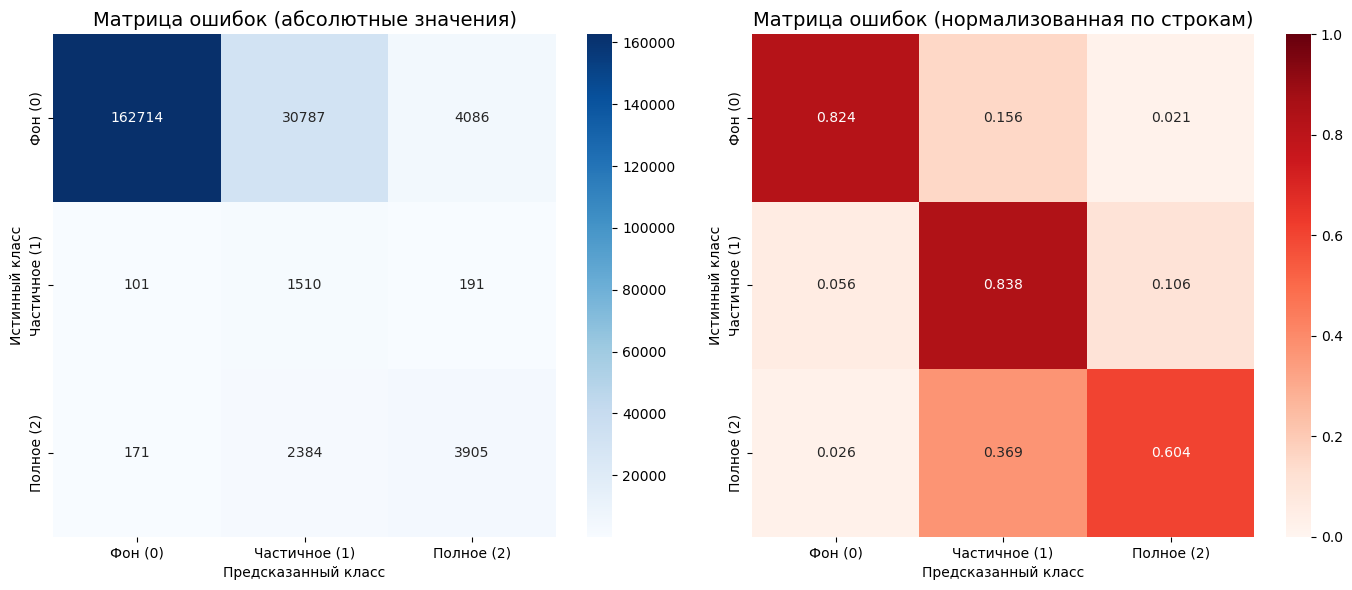


ВЫВОДЫ ПО ОШИБКАМ

Класс 1 (частичное ДЭПД) чаще всего ошибочно предсказывается как класс 2
  → Частичное ДЭПД путается с ПОЛНЫМ ДЭПД (модель переоценивает)

Класс 2 (полное ДЭПД) чаще всего ошибочно предсказывается как класс 1
  → Полное ДЭПД путается с ЧАСТИЧНЫМ (модель недооценивает)

Класс 0 (фон) чаще всего ошибочно предсказывается как класс 1
  → Фон путается с ЧАСТИЧНЫМ ДЭПД (ложные срабатывания на артефактах)

ГОТОВО!


In [45]:
# ============================================================
# АНАЛИЗ ОШИБОК ТРЁХКЛАССОВОЙ CNN
# ============================================================

print("="*80)
print("АНАЛИЗ ОШИБОК: С КАКИМ КЛАССОМ ПУТАЕТ CNN")
print("="*80)

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Предполагается, что y_true, y_pred уже определены
# y_true - истинные метки (0,1,2)
# y_pred - предсказанные классы

print("\n1. МАТРИЦА ОШИБОК (НОРМАЛИЗОВАННАЯ ПО СТРОКАМ)")
print("="*80)

# Полная матрица ошибок
cm = confusion_matrix(y_true, y_pred)
print("\nАбсолютная матрица ошибок:")
print(cm)
print(f"  Строки: истинные классы")
print(f"  Столбцы: предсказанные классы")

# Нормализованная по строкам (доля ошибок внутри каждого класса)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\nНормализованная матрица ошибок (по строкам):")
print(np.round(cm_norm, 3))
print("  Строки: истинные классы")
print("  Столбцы: предсказанные классы")

# ============================================================
# 2. ДЕТАЛЬНЫЙ АНАЛИЗ КЛАССА 1 (частичное ДЭПД)
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ КЛАССА 1 (ЧАСТИЧНОЕ ДЭПД)")
print("="*80)

# Индексы окон, где истинный класс = 1
class1_indices = np.where(y_true == 1)[0]
print(f"\nВсего окон класса 1: {len(class1_indices)}")

if len(class1_indices) > 0:
    # Распределение предсказаний для класса 1
    pred_class1 = y_pred[class1_indices]
    unique, counts = np.unique(pred_class1, return_counts=True)
    
    print(f"\nРаспределение предсказаний для истинного класса 1:")
    for cls, cnt in zip(unique, counts):
        pct = cnt / len(class1_indices) * 100
        print(f"  Предсказано как класс {cls}: {cnt} ({pct:.1f}%)")
    
    # Куда чаще всего ошибается класс 1?
    errors_class1 = pred_class1 != 1
    print(f"\nОшибки класса 1: {errors_class1.sum()} из {len(class1_indices)} ({errors_class1.sum()/len(class1_indices)*100:.1f}%)")
    
    if errors_class1.sum() > 0:
        error_dist = pred_class1[errors_class1]
        unique_err, counts_err = np.unique(error_dist, return_counts=True)
        print(f"  Из них предсказано как:")
        for cls, cnt in zip(unique_err, counts_err):
            pct = cnt / errors_class1.sum() * 100
            print(f"    Класс {cls}: {cnt} ({pct:.1f}%)")

# ============================================================
# 3. ДЕТАЛЬНЫЙ АНАЛИЗ КЛАССА 2 (полное ДЭПД)
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ КЛАССА 2 (ПОЛНОЕ ДЭПД)")
print("="*80)

class2_indices = np.where(y_true == 2)[0]
print(f"\nВсего окон класса 2: {len(class2_indices)}")

if len(class2_indices) > 0:
    pred_class2 = y_pred[class2_indices]
    unique, counts = np.unique(pred_class2, return_counts=True)
    
    print(f"\nРаспределение предсказаний для истинного класса 2:")
    for cls, cnt in zip(unique, counts):
        pct = cnt / len(class2_indices) * 100
        print(f"  Предсказано как класс {cls}: {cnt} ({pct:.1f}%)")
    
    errors_class2 = pred_class2 != 2
    print(f"\nОшибки класса 2: {errors_class2.sum()} из {len(class2_indices)} ({errors_class2.sum()/len(class2_indices)*100:.1f}%)")
    
    if errors_class2.sum() > 0:
        error_dist = pred_class2[errors_class2]
        unique_err, counts_err = np.unique(error_dist, return_counts=True)
        print(f"  Из них предсказано как:")
        for cls, cnt in zip(unique_err, counts_err):
            pct = cnt / errors_class2.sum() * 100
            print(f"    Класс {cls}: {cnt} ({pct:.1f}%)")

# ============================================================
# 4. ДЕТАЛЬНЫЙ АНАЛИЗ КЛАССА 0 (фон)
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ КЛАССА 0 (ФОН)")
print("="*80)

class0_indices = np.where(y_true == 0)[0]
print(f"\nВсего окон класса 0: {len(class0_indices)}")

if len(class0_indices) > 0:
    pred_class0 = y_pred[class0_indices]
    unique, counts = np.unique(pred_class0, return_counts=True)
    
    print(f"\nРаспределение предсказаний для истинного класса 0:")
    for cls, cnt in zip(unique, counts):
        pct = cnt / len(class0_indices) * 100
        print(f"  Предсказано как класс {cls}: {cnt} ({pct:.1f}%)")
    
    errors_class0 = pred_class0 != 0
    print(f"\nОшибки класса 0: {errors_class0.sum()} из {len(class0_indices)} ({errors_class0.sum()/len(class0_indices)*100:.1f}%)")
    
    if errors_class0.sum() > 0:
        error_dist = pred_class0[errors_class0]
        unique_err, counts_err = np.unique(error_dist, return_counts=True)
        print(f"  Из них предсказано как:")
        for cls, cnt in zip(unique_err, counts_err):
            pct = cnt / errors_class0.sum() * 100
            print(f"    Класс {cls}: {cnt} ({pct:.1f}%)")

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК
# ============================================================

print("\n" + "="*80)
print("ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Абсолютная матрица
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Фон (0)', 'Частичное (1)', 'Полное (2)'],
            yticklabels=['Фон (0)', 'Частичное (1)', 'Полное (2)'],
            ax=ax1)
ax1.set_title('Матрица ошибок (абсолютные значения)', fontsize=14)
ax1.set_xlabel('Предсказанный класс')
ax1.set_ylabel('Истинный класс')

# Нормализованная матрица
ax2 = axes[1]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Reds', 
            xticklabels=['Фон (0)', 'Частичное (1)', 'Полное (2)'],
            yticklabels=['Фон (0)', 'Частичное (1)', 'Полное (2)'],
            ax=ax2, vmin=0, vmax=1)
ax2.set_title('Матрица ошибок (нормализованная по строкам)', fontsize=14)
ax2.set_xlabel('Предсказанный класс')
ax2.set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

# ============================================================
# 6. ВЫВОДЫ
# ============================================================

print("\n" + "="*80)
print("ВЫВОДЫ ПО ОШИБКАМ")
print("="*80)

# Определяем основной тип ошибки для каждого класса
if len(class1_indices) > 0:
    pred_class1 = y_pred[class1_indices]
    errors_class1 = pred_class1 != 1
    if errors_class1.sum() > 0:
        main_error_class1 = np.bincount(pred_class1[errors_class1]).argmax()
        print(f"\nКласс 1 (частичное ДЭПД) чаще всего ошибочно предсказывается как класс {main_error_class1}")
        if main_error_class1 == 0:
            print("  → Частичное ДЭПД путается с ФОНОМ (модель не видит слабый сигнал)")
        elif main_error_class1 == 2:
            print("  → Частичное ДЭПД путается с ПОЛНЫМ ДЭПД (модель переоценивает)")

if len(class2_indices) > 0:
    pred_class2 = y_pred[class2_indices]
    errors_class2 = pred_class2 != 2
    if errors_class2.sum() > 0:
        main_error_class2 = np.bincount(pred_class2[errors_class2]).argmax()
        print(f"\nКласс 2 (полное ДЭПД) чаще всего ошибочно предсказывается как класс {main_error_class2}")
        if main_error_class2 == 0:
            print("  → Полное ДЭПД путается с ФОНОМ (пропуск эпилептиформной активности!)")
        elif main_error_class2 == 1:
            print("  → Полное ДЭПД путается с ЧАСТИЧНЫМ (модель недооценивает)")

if len(class0_indices) > 0:
    pred_class0 = y_pred[class0_indices]
    errors_class0 = pred_class0 != 0
    if errors_class0.sum() > 0:
        main_error_class0 = np.bincount(pred_class0[errors_class0]).argmax()
        print(f"\nКласс 0 (фон) чаще всего ошибочно предсказывается как класс {main_error_class0}")
        if main_error_class0 == 1:
            print("  → Фон путается с ЧАСТИЧНЫМ ДЭПД (ложные срабатывания на артефактах)")
        elif main_error_class0 == 2:
            print("  → Фон путается с ПОЛНЫМ ДЭПД (серьёзные ложные срабатывания)")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

### Результаты обучения со взвешенными классами


  
Epoch 15/50  
  Train loss: 0.574408  
  Val F1: class0=0.9218, class1=0.1010, class2=0.4885  
  Macro F1: 0.5038, Weighted F1: 0.9010  

Early stopping triggered after 15 epochs  

 
##### ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ   

Classification Report:
                precision    recall  f1-score   support  

           Фон       1.00      0.86      0.92    197587  
Частичное ДЭПД       0.05      0.70      0.10      1802  
   Полное ДЭПД       0.36      0.74      0.49      6460  

      accuracy                           0.85    205849  
     macro avg       0.47      0.76      0.50    205849  
  weighted avg       0.97      0.85      0.90    205849  


    
##### ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ КЛАССА 'ПОЛНОЕ ДЭПД' (класс 2)    

По критерию МАКСИМАЛЬНЫЙ F1:  
  Оптимальный порог: 0.6426  
  F1: 0.5642  
  Precision: 0.5426  
  Recall: 0.5873  

# Пациент неспецифичная модель

In [46]:
# ============================================================
# ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ ДЛЯ CNN
# ============================================================

print("="*80)
print("ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ")
print("="*80)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report, precision_recall_curve
from sklearn.model_selection import train_test_split
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# ============================================================
# 1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ
# ============================================================

print("\n1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ")

# Собираем данные с привязкой к пациенту (external_id)
patient_data = defaultdict(lambda: {'X': [], 'y': []})

for rec_id, rec_data in dataset['records'].items():
    external_id = rec_data['external_id']
    for win in rec_data['windows']:
        patient_data[external_id]['X'].append(win['data'].flatten())
        patient_data[external_id]['y'].append(win['depd_frac'])

print(f"Всего пациентов: {len(patient_data)}")

# Статистика по каждому пациенту
patient_stats = []
for pid, data in patient_data.items():
    y_arr = np.array(data['y'])
    n_total = len(y_arr)
    n_depd = np.sum(y_arr > 0)
    patient_stats.append({
        'patient_id': pid,
        'n_windows': n_total,
        'n_depd': n_depd,
        'depd_ratio': n_depd / n_total if n_total > 0 else 0
    })

patient_stats_df = pd.DataFrame(patient_stats)
print(f"\nСтатистика по пациентам:")
print(f"  Всего окон: {patient_stats_df['n_windows'].sum()}")
print(f"  Всего ДЭПД окон: {patient_stats_df['n_depd'].sum()}")
print(f"  Среднее окон на пациента: {patient_stats_df['n_windows'].mean():.1f}")
print(f"  Медиана окон на пациента: {patient_stats_df['n_windows'].median():.1f}")

# ============================================================
# 2. ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ
# ============================================================

print("\n2. ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ")

# Получаем список пациентов
patients = list(patient_data.keys())
print(f"Всего пациентов: {len(patients)}")

# Стратифицированное разбиение пациентов по наличию ДЭПД
patient_has_depd = [1 if patient_stats_df[patient_stats_df['patient_id'] == pid]['n_depd'].values[0] > 0 else 0 for pid in patients]

train_patients, test_patients = train_test_split(
    patients, test_size=0.2, random_state=42, stratify=patient_has_depd
)

print(f"\nТренировочных пациентов: {len(train_patients)}")
print(f"Тестовых пациентов: {len(test_patients)}")

# Собираем данные по пациентам
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

for pid in train_patients:
    X_train_list.extend(patient_data[pid]['X'])
    y_train_list.extend(patient_data[pid]['y'])

for pid in test_patients:
    X_test_list.extend(patient_data[pid]['X'])
    y_test_list.extend(patient_data[pid]['y'])

X_train = np.array(X_train_list, dtype=np.float32)
y_train = np.array(y_train_list, dtype=np.float32)
X_test = np.array(X_test_list, dtype=np.float32)
y_test = np.array(y_test_list, dtype=np.float32)

print(f"\nТренировочная выборка: {len(X_train)} окон")
print(f"  ДЭПД (y>0): {np.sum(y_train > 0)}")
print(f"  Фон (y==0): {np.sum(y_train == 0)}")
print(f"\nТестовая выборка: {len(X_test)} окон")
print(f"  ДЭПД (y>0): {np.sum(y_test > 0)}")
print(f"  Фон (y==0): {np.sum(y_test == 0)}")

# ============================================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ CNN
# ============================================================

N_CHANNELS = 18
N_TIMEPOINTS = 200

X_train_cnn = X_train.reshape(-1, N_CHANNELS, N_TIMEPOINTS)
X_test_cnn = X_test.reshape(-1, N_CHANNELS, N_TIMEPOINTS)

# Нормализация (только по тренировочным данным!)
mean = X_train_cnn.mean(axis=(0, 2), keepdims=True)
std = X_train_cnn.std(axis=(0, 2), keepdims=True) + 1e-8
X_train_cnn = (X_train_cnn - mean) / std
X_test_cnn = (X_test_cnn - mean) / std

# Конвертация в тензоры
X_train_tensor = torch.FloatTensor(X_train_cnn)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_cnn)
y_test_tensor = torch.FloatTensor(y_test)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

# ============================================================
# 4. АРХИТЕКТУРА CNN
# ============================================================

class CNNBinary(nn.Module):
    def __init__(self, n_channels=18, n_timepoints=200):
        super(CNNBinary, self).__init__()
        
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.3)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding='same')
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.3)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.AdaptiveAvgPool1d(1)
        self.dropout3 = nn.Dropout(0.4)
        
        self.fc1 = nn.Linear(256, 128)
        self.dropout4 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout5 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.dropout1(self.pool1(torch.relu(self.bn1(self.conv1(x)))))
        x = self.dropout2(self.pool2(torch.relu(self.bn2(self.conv2(x)))))
        x = self.dropout3(self.pool3(torch.relu(self.bn3(self.conv3(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout4(torch.relu(self.fc1(x)))
        x = self.dropout5(torch.relu(self.fc2(x)))
        x = self.sigmoid(self.fc3(x)).squeeze()
        return x

model = CNNBinary().to(device)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================
# 5. ФУНКЦИЯ ПОТЕРЬ И ОПТИМИЗАТОР
# ============================================================

# Веса для компенсации дисбаланса (только для ДЭПД)
y_train_binary = (y_train > 0).astype(int)
pos_weight = len(y_train_binary[y_train_binary == 0]) / len(y_train_binary[y_train_binary == 1])
pos_weight_tensor = torch.FloatTensor([pos_weight]).to(device)
print(f"Positive weight: {pos_weight:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ============================================================
# 6. ФУНКЦИЯ ВАЛИДАЦИИ
# ============================================================

def validate(model, loader, device):
    model.eval()
    y_true_list = []
    y_pred_list = []
    y_proba_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probas = torch.sigmoid(logits)
            
            y_true_list.extend(y_batch.numpy())
            y_pred_list.extend((probas > 0.5).cpu().numpy().astype(int))
            y_proba_list.extend(probas.cpu().numpy())
    
    return np.array(y_true_list), np.array(y_pred_list), np.array(y_proba_list)

# ============================================================
# 7. ОБУЧЕНИЕ
# ============================================================

print("\n" + "="*80)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*80)

num_epochs = 30
best_val_f1 = 0
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Валидация
    y_true, y_pred, y_proba = validate(model, test_loader, device)
    y_true_binary = (y_true > 0).astype(int)
    
    f1 = f1_score(y_true_binary, y_pred)
    prec = precision_score(y_true_binary, y_pred)
    rec = recall_score(y_true_binary, y_pred)
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {avg_train_loss:.6f}")
    print(f"  Val F1: {f1:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")
    
    scheduler.step(avg_train_loss)
    
    if f1 > best_val_f1:
        best_val_f1 = f1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  -> New best model! (val_f1: {f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

# Восстанавливаем лучшую модель
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# ============================================================
# 8. ФИНАЛЬНАЯ ОЦЕНКА
# ============================================================

print("\n" + "="*80)
print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
print("="*80)

y_true, y_pred, y_proba = validate(model, test_loader, device)
y_true_binary = (y_true > 0).astype(int)

print("\nМетрики при пороге 0.5:")
print(f"  F1: {f1_score(y_true_binary, y_pred):.4f}")
print(f"  Precision: {precision_score(y_true_binary, y_pred):.4f}")
print(f"  Recall: {recall_score(y_true_binary, y_pred):.4f}")
print(f"  AUC: {roc_auc_score(y_true_binary, y_proba):.4f}")

# Оптимизация порога
precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba > best_threshold).astype(int)
best_prec = precision_score(y_true_binary, y_pred_opt)
best_rec = recall_score(y_true_binary, y_pred_opt)

print(f"\nОптимизация порога:")
print(f"  Оптимальный порог: {best_threshold:.4f}")
print(f"  F1: {best_f1:.4f}")
print(f"  Precision: {best_prec:.4f}")
print(f"  Recall: {best_rec:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_true_binary, y_pred_opt)
print(f"\nМатрица ошибок (порог {best_threshold:.4f}):")
print(cm)
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ
Используется устройство: cuda

1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ
Всего пациентов: 57

Статистика по пациентам:
  Всего окон: 1029244
  Всего ДЭПД окон: 44153
  Среднее окон на пациента: 18056.9
  Медиана окон на пациента: 1141.0

2. ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ
Всего пациентов: 57

Тренировочных пациентов: 45
Тестовых пациентов: 12

Тренировочная выборка: 626598 окон
  ДЭПД (y>0): 22473
  Фон (y==0): 604125

Тестовая выборка: 402646 окон
  ДЭПД (y>0): 21680
  Фон (y==0): 380966
CNNBinary(
  (conv1): Conv1d(18, 64, kernel_size=(5,), stride=(1,), padding=same)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel

Epoch 1/30: 100%|██████████| 2448/2448 [00:23<00:00, 102.73it/s, loss=0.783]



Epoch 1/30
  Train loss: 0.835885
  Val F1: 0.1527, Precision: 0.0834, Recall: 0.8959
  -> New best model! (val_f1: 0.1527)


Epoch 2/30: 100%|██████████| 2448/2448 [00:23<00:00, 104.95it/s, loss=0.738]



Epoch 2/30
  Train loss: 0.829387
  Val F1: 0.1533, Precision: 0.0837, Recall: 0.9097
  -> New best model! (val_f1: 0.1533)


...


Epoch 18/30
  Train loss: 0.807770
  Val F1: 0.3110, Precision: 0.1982, Recall: 0.7222


Epoch 19/30: 100%|██████████| 2448/2448 [00:23<00:00, 104.27it/s, loss=0.848]



Epoch 19/30
  Train loss: 0.807167
  Val F1: 0.3262, Precision: 0.2136, Recall: 0.6904


Epoch 20/30: 100%|██████████| 2448/2448 [00:30<00:00, 80.14it/s, loss=0.751] 



Epoch 20/30
  Train loss: 0.806961
  Val F1: 0.2934, Precision: 0.1834, Recall: 0.7330

Early stopping triggered after 20 epochs

ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ

Метрики при пороге 0.5:
  F1: 0.2934
  Precision: 0.1834
  Recall: 0.7330
  AUC: 0.7996

Оптимизация порога:
  Оптимальный порог: 0.7132
  F1: 0.3814
  Precision: 0.2925
  Recall: 0.5477

Матрица ошибок (порог 0.7132):
[[352240  28726]
 [  9805  11875]]
  TN: 352240, FP: 28726
  FN: 9805, TP: 11875

ГОТОВО!


In [47]:
# ============================================================
# ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ С ФИКСИРОВАННЫМ ТЕСТОМ
# ============================================================

print("="*80)
print("ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ (ФИКСИРОВАННЫЙ ТЕСТ)")
print("="*80)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, confusion_matrix
from sklearn.model_selection import train_test_split
from collections import defaultdict
import pandas as pd
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# ============================================================
# 1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ
# ============================================================

print("\n1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ")

patient_data = defaultdict(lambda: {'X': [], 'y': []})

for rec_id, rec_data in dataset['records'].items():
    external_id = rec_data['external_id']
    for win in rec_data['windows']:
        patient_data[external_id]['X'].append(win['data'].flatten())
        patient_data[external_id]['y'].append(win['depd_frac'])

print(f"Всего пациентов: {len(patient_data)}")

# Статистика по пациентам
patient_stats = []
for pid, data in patient_data.items():
    y_arr = np.array(data['y'])
    n_total = len(y_arr)
    n_depd = np.sum(y_arr > 0)
    patient_stats.append({
        'patient_id': pid,
        'n_windows': n_total,
        'n_depd': n_depd,
        'depd_ratio': n_depd / n_total if n_total > 0 else 0
    })

patient_stats_df = pd.DataFrame(patient_stats)
patient_stats_df = patient_stats_df.sort_values('n_depd', ascending=False)
print(f"\nТоп пациентов по количеству ДЭПД окон:")
print(patient_stats_df.head(10).to_string(index=False))

# ============================================================
# 2. ОТБОР ПАЦИЕНТОВ ДЛЯ ТЕСТА (ФИКСИРОВАННОЕ КОЛИЧЕСТВО ДЭПД)
# ============================================================

print("\n2. ОТБОР ПАЦИЕНТОВ ДЛЯ ТЕСТОВОЙ ВЫБОРКИ")

# Целевое количество ДЭПД в тесте (2000-4000)
TARGET_DEPD_IN_TEST = 3000

# Сортируем пациентов по количеству ДЭПД (начиная с самых "богатых")
sorted_patients = patient_stats_df.sort_values('n_depd', ascending=False)['patient_id'].tolist()

test_patients = []
total_depd_in_test = 0

for pid in sorted_patients:
    n_depd = patient_stats_df[patient_stats_df['patient_id'] == pid]['n_depd'].values[0]
    if total_depd_in_test + n_depd <= TARGET_DEPD_IN_TEST:
        test_patients.append(pid)
        total_depd_in_test += n_depd
    else:
        # Если добавление этого пациента превысит лимит, останавливаемся
        # (можно было бы взять часть пациента, но для пациент-независимости - нет)
        pass

# Остальные пациенты - в трейн
train_patients = [pid for pid in patient_stats_df['patient_id'].tolist() if pid not in test_patients]

print(f"\nТестовых пациентов: {len(test_patients)}")
print(f"Тренировочных пациентов: {len(train_patients)}")
print(f"ДЭПД окон в тесте: {total_depd_in_test}")

# Детали тестовых пациентов
print(f"\nТестовые пациенты:")
test_stats = patient_stats_df[patient_stats_df['patient_id'].isin(test_patients)]
print(test_stats[['patient_id', 'n_windows', 'n_depd']].to_string(index=False))

# ============================================================
# 3. СБОР ДАННЫХ ПО ВЫБРАННЫМ ПАЦИЕНТАМ
# ============================================================

print("\n3. СБОР ДАННЫХ ПО ВЫБРАННЫМ ПАЦИЕНТАМ")

X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

for pid in train_patients:
    X_train_list.extend(patient_data[pid]['X'])
    y_train_list.extend(patient_data[pid]['y'])

for pid in test_patients:
    X_test_list.extend(patient_data[pid]['X'])
    y_test_list.extend(patient_data[pid]['y'])

X_train = np.array(X_train_list, dtype=np.float32)
y_train = np.array(y_train_list, dtype=np.float32)
X_test = np.array(X_test_list, dtype=np.float32)
y_test = np.array(y_test_list, dtype=np.float32)

print(f"\nТренировочная выборка: {len(X_train)} окон")
print(f"  ДЭПД (y>0): {np.sum(y_train > 0)} ({np.sum(y_train > 0)/len(X_train)*100:.2f}%)")
print(f"  Фон (y==0): {np.sum(y_train == 0)}")
print(f"\nТестовая выборка: {len(X_test)} окон")
print(f"  ДЭПД (y>0): {np.sum(y_test > 0)} ({np.sum(y_test > 0)/len(X_test)*100:.2f}%)")
print(f"  Фон (y==0): {np.sum(y_test == 0)}")

# ============================================================
# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ CNN
# ============================================================

N_CHANNELS = 18
N_TIMEPOINTS = 200

X_train_cnn = X_train.reshape(-1, N_CHANNELS, N_TIMEPOINTS)
X_test_cnn = X_test.reshape(-1, N_CHANNELS, N_TIMEPOINTS)

# Нормализация (только по тренировочным данным!)
mean = X_train_cnn.mean(axis=(0, 2), keepdims=True)
std = X_train_cnn.std(axis=(0, 2), keepdims=True) + 1e-8
X_train_cnn = (X_train_cnn - mean) / std
X_test_cnn = (X_test_cnn - mean) / std

# Конвертация в тензоры
X_train_tensor = torch.FloatTensor(X_train_cnn)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_cnn)
y_test_tensor = torch.FloatTensor(y_test)

# DataLoader (уменьшаем batch size для большей стабильности)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

# ============================================================
# 5. АРХИТЕКТУРА CNN (упрощённая для предотвращения переобучения)
# ============================================================

class CNNBinary(nn.Module):
    def __init__(self, n_channels=18, n_timepoints=200):
        super(CNNBinary, self).__init__()
        
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.25)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding='same')
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.25)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.AdaptiveAvgPool1d(1)
        self.dropout3 = nn.Dropout(0.3)
        
        self.fc1 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 32)
        self.dropout5 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.dropout1(self.pool1(torch.relu(self.bn1(self.conv1(x)))))
        x = self.dropout2(self.pool2(torch.relu(self.bn2(self.conv2(x)))))
        x = self.dropout3(self.pool3(torch.relu(self.bn3(self.conv3(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout4(torch.relu(self.fc1(x)))
        x = self.dropout5(torch.relu(self.fc2(x)))
        x = self.sigmoid(self.fc3(x)).squeeze()
        return x

model = CNNBinary().to(device)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

# Веса для компенсации дисбаланса
y_train_binary = (y_train > 0).astype(int)
pos_weight = len(y_train_binary[y_train_binary == 0]) / len(y_train_binary[y_train_binary == 1])
pos_weight_tensor = torch.FloatTensor([pos_weight]).to(device)
print(f"Positive weight: {pos_weight:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # уменьшили learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ============================================================
# 6. ОБУЧЕНИЕ
# ============================================================

print("\n" + "="*80)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*80)

def validate(model, loader, device):
    model.eval()
    y_true_list = []
    y_proba_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probas = torch.sigmoid(logits)
            
            y_true_list.extend(y_batch.numpy())
            y_proba_list.extend(probas.cpu().numpy())
    
    return np.array(y_true_list), np.array(y_proba_list)

num_epochs = 30
best_val_f1 = 0
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Валидация
    y_true, y_proba = validate(model, test_loader, device)
    y_true_binary = (y_true > 0).astype(int)
    
    # Поиск оптимального порога на валидации
    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    if len(f1_scores) > 1:
        best_idx = np.argmax(f1_scores[:-1])
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        
        y_pred = (y_proba > best_threshold).astype(int)
        prec = precision_score(y_true_binary, y_pred)
        rec = recall_score(y_true_binary, y_pred)
    else:
        best_f1 = 0
        best_threshold = 0.5
        prec = 0
        rec = 0
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {avg_train_loss:.6f}")
    print(f"  Val (opt threshold={best_threshold:.4f}): F1={best_f1:.4f}, P={prec:.4f}, R={rec:.4f}")
    
    scheduler.step(avg_train_loss)
    
    if best_f1 > best_val_f1:
        best_val_f1 = best_f1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  -> New best model! (val_f1: {best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

# Восстанавливаем лучшую модель
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# ============================================================
# 7. ФИНАЛЬНАЯ ОЦЕНКА
# ============================================================

print("\n" + "="*80)
print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
print("="*80)

y_true, y_proba = validate(model, test_loader, device)
y_true_binary = (y_true > 0).astype(int)

# Оптимизация порога на тесте
precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba > best_threshold).astype(int)
best_prec = precision_score(y_true_binary, y_pred_opt)
best_rec = recall_score(y_true_binary, y_pred_opt)
auc = roc_auc_score(y_true_binary, y_proba)

print(f"\nРезультаты на тестовой выборке:")
print(f"  Размер теста: {len(y_true)} окон")
print(f"  ДЭПД в тесте: {np.sum(y_true_binary)} ({np.sum(y_true_binary)/len(y_true)*100:.2f}%)")
print(f"\nОптимальный порог: {best_threshold:.4f}")
print(f"  F1: {best_f1:.4f}")
print(f"  Precision: {best_prec:.4f}")
print(f"  Recall: {best_rec:.4f}")
print(f"  AUC: {auc:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_true_binary, y_pred_opt)
print(f"\nМатрица ошибок:")
print(cm)
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")

# Метрики при разных порогах
print(f"\nМетрики для разных порогов:")
print(f"{'Порог':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 38)
for thr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_bin = (y_proba > thr).astype(int)
    f1 = f1_score(y_true_binary, y_pred_bin)
    prec = precision_score(y_true_binary, y_pred_bin)
    rec = recall_score(y_true_binary, y_pred_bin)
    print(f"{thr:8.2f} {f1:8.4f} {prec:10.4f} {rec:8.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ПАЦИЕНТ-НЕЗАВИСИМОЕ РАЗДЕЛЕНИЕ (ФИКСИРОВАННЫЙ ТЕСТ)
Используется устройство: cuda

1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ
Всего пациентов: 57

Топ пациентов по количеству ДЭПД окон:
            patient_id  n_windows  n_depd  depd_ratio
  patient_009_FA0183ZO     112333   20217    0.179974
          005_FA0183ZO      22217    8326    0.374758
patient_1.002_GA1501CO      30323    5551    0.183062
          000_FA0183FS      21076    2308    0.109508
          008_GA15011B      70345    1432    0.020357
        2.050_DA0236Q8     262487     562    0.002141
        2.048_DA0236PQ       3699     538    0.145445
        2.042_FA0015HC      32165     327    0.010166
        2.043_FA0015GR      16246     315    0.019389
        2.047_FA0015BC        808     280    0.346535

2. ОТБОР ПАЦИЕНТОВ ДЛЯ ТЕСТОВОЙ ВЫБОРКИ

Тестовых пациентов: 3
Тренировочных пациентов: 54
ДЭПД окон в тесте: 2997

Тестовые пациенты:
    patient_id  n_windows  n_depd
  000_FA0183FS      21076    2308
2.050_DA0236Q8     262487     5

Epoch 1/30: 100%|██████████| 5814/5814 [00:58<00:00, 99.98it/s, loss=1.14]  



Epoch 1/30
  Train loss: 0.848550
  Val (opt threshold=0.5000): F1=0.0224, P=0.0111, R=0.7324
  -> New best model! (val_f1: 0.0224)


Epoch 2/30: 100%|██████████| 5814/5814 [00:57<00:00, 101.08it/s, loss=0.99] 



Epoch 2/30
  Train loss: 0.840060
  Val (opt threshold=0.5000): F1=0.0208, P=0.0046, R=0.1952


...


Epoch 9/30
  Train loss: 0.825063
  Val (opt threshold=0.5000): F1=0.0208, P=0.0032, R=0.0187


Epoch 10/30: 100%|██████████| 5814/5814 [00:56<00:00, 103.58it/s, loss=0.714]



Epoch 10/30
  Train loss: 0.824380
  Val (opt threshold=0.5000): F1=0.0208, P=0.0021, R=0.0117


Epoch 11/30: 100%|██████████| 5814/5814 [00:56<00:00, 103.42it/s, loss=0.829]



Epoch 11/30
  Train loss: 0.823728
  Val (opt threshold=0.5000): F1=0.0208, P=0.0045, R=0.0878

Early stopping triggered after 11 epochs

ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ

Результаты на тестовой выборке:
  Размер теста: 285125 окон
  ДЭПД в тесте: 2997 (1.05%)

Оптимальный порог: 0.5000
  F1: 0.0208
  Precision: 0.0045
  Recall: 0.0878
  AUC: 0.4384

Матрица ошибок:
[[223389  58739]
 [  2734    263]]
  TN: 223389, FP: 58739
  FN: 2734, TP: 263

Метрики для разных порогов:
   Порог       F1  Precision   Recall
--------------------------------------
    0.10   0.0208     0.0105   1.0000
    0.20   0.0208     0.0105   1.0000
    0.30   0.0208     0.0105   1.0000
    0.40   0.0208     0.0105   1.0000
    0.50   0.0085     0.0045   0.0878
    0.60   0.0009     0.0008   0.0010
    0.70   0.0000     0.0000   0.0000
    0.80   0.0000     0.0000   0.0000
    0.90   0.0000     0.0000   0.0000

ГОТОВО!


In [49]:
# ============================================================
# ПАЦИЕНТ-НОРМАЛИЗАЦИЯ + CNN
# ============================================================

print("="*80)
print("ПАЦИЕНТ-НОРМАЛИЗАЦИЯ: ВЫЧИТАНИЕ СРЕДНЕГО ПО ПАЦИЕНТУ")
print("="*80)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, confusion_matrix
from sklearn.model_selection import train_test_split
from collections import defaultdict
import pandas as pd
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# ============================================================
# 1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ
# ============================================================

print("\n1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ")

patient_data = defaultdict(lambda: {'X': [], 'y': []})

for rec_id, rec_data in dataset['records'].items():
    external_id = rec_data['external_id']
    for win in rec_data['windows']:
        patient_data[external_id]['X'].append(win['data'])  # сохраняем в исходной форме (18,200)
        patient_data[external_id]['y'].append(win['depd_frac'])

print(f"Всего пациентов: {len(patient_data)}")

# Статистика по пациентам
patient_stats = []
for pid, data in patient_data.items():
    y_arr = np.array(data['y'])
    n_total = len(y_arr)
    n_depd = np.sum(y_arr > 0)
    patient_stats.append({
        'patient_id': pid,
        'n_windows': n_total,
        'n_depd': n_depd,
        'depd_ratio': n_depd / n_total if n_total > 0 else 0
    })

patient_stats_df = pd.DataFrame(patient_stats)
patient_stats_df = patient_stats_df.sort_values('n_depd', ascending=False)
print(f"\nТоп пациентов по количеству ДЭПД окон:")
print(patient_stats_df.head(10).to_string(index=False))

# ============================================================
# 2. ОТБОР ПАЦИЕНТОВ ДЛЯ ТЕСТА
# ============================================================

print("\n2. ОТБОР ПАЦИЕНТОВ ДЛЯ ТЕСТОВОЙ ВЫБОРКИ")

TARGET_DEPD_IN_TEST = 3000

sorted_patients = patient_stats_df.sort_values('n_depd', ascending=False)['patient_id'].tolist()

test_patients = []
total_depd_in_test = 0

for pid in sorted_patients:
    n_depd = patient_stats_df[patient_stats_df['patient_id'] == pid]['n_depd'].values[0]
    if total_depd_in_test + n_depd <= TARGET_DEPD_IN_TEST:
        test_patients.append(pid)
        total_depd_in_test += n_depd

train_patients = [pid for pid in patient_stats_df['patient_id'].tolist() if pid not in test_patients]

print(f"\nТестовых пациентов: {len(test_patients)}")
print(f"Тренировочных пациентов: {len(train_patients)}")
print(f"ДЭПД окон в тесте: {total_depd_in_test}")

# ============================================================
# 3. ПАЦИЕНТ-НОРМАЛИЗАЦИЯ
# ============================================================

print("\n3. ПАЦИЕНТ-НОРМАЛИЗАЦИЯ (вычитание среднего по каждому пациенту)")

def normalize_patient_data(patient_windows):
    """
    Нормализует данные пациента: вычитает среднее по каждому каналу и каждому временному отсчёту
    """
    # patient_windows: list of arrays (18, 200)
    # Стекируем все окна пациента
    stacked = np.stack(patient_windows, axis=0)  # (n_windows, 18, 200)
    
    # Вычисляем среднее по каждому каналу и временному отсчёту для этого пациента
    # (усредняем по окнам)
    mean = np.mean(stacked, axis=0, keepdims=True)  # (1, 18, 200)
    std = np.std(stacked, axis=0, keepdims=True) + 1e-8
    
    # Нормализуем каждое окно
    normalized = (stacked - mean) / std
    
    return normalized.reshape(-1, 18 * 200)  # (n_windows, 3600)

# Применяем нормализацию к каждому пациенту
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

print("\nНормализация тренировочных пациентов...")
for pid in tqdm(train_patients):
    patient_windows = patient_data[pid]['X']
    patient_labels = patient_data[pid]['y']
    
    # Нормализуем окна пациента
    normalized = normalize_patient_data(patient_windows)
    
    X_train_list.append(normalized)
    y_train_list.extend(patient_labels)

print("Нормализация тестовых пациентов...")
for pid in tqdm(test_patients):
    patient_windows = patient_data[pid]['X']
    patient_labels = patient_data[pid]['y']
    
    # Для тестовых пациентов используем ИХ СОБСТВЕННОЕ среднее и std
    normalized = normalize_patient_data(patient_windows)
    
    X_test_list.append(normalized)
    y_test_list.extend(patient_labels)

X_train = np.concatenate(X_train_list, axis=0).astype(np.float32)
y_train = np.array(y_train_list, dtype=np.float32)
X_test = np.concatenate(X_test_list, axis=0).astype(np.float32)
y_test = np.array(y_test_list, dtype=np.float32)

print(f"\nТренировочная выборка: {len(X_train)} окон")
print(f"  ДЭПД (y>0): {np.sum(y_train > 0)} ({np.sum(y_train > 0)/len(X_train)*100:.2f}%)")
print(f"\nТестовая выборка: {len(X_test)} окон")
print(f"  ДЭПД (y>0): {np.sum(y_test > 0)} ({np.sum(y_test > 0)/len(X_test)*100:.2f}%)")

# ============================================================
# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ CNN
# ============================================================

N_CHANNELS = 18
N_TIMEPOINTS = 200

X_train_cnn = X_train.reshape(-1, N_CHANNELS, N_TIMEPOINTS)
X_test_cnn = X_test.reshape(-1, N_CHANNELS, N_TIMEPOINTS)

# Дополнительная глобальная нормализация (для стабильности)
mean_global = X_train_cnn.mean(axis=(0, 2), keepdims=True)
std_global = X_train_cnn.std(axis=(0, 2), keepdims=True) + 1e-8
X_train_cnn = (X_train_cnn - mean_global) / std_global
X_test_cnn = (X_test_cnn - mean_global) / std_global

# Конвертация в тензоры
X_train_tensor = torch.FloatTensor(X_train_cnn)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_cnn)
y_test_tensor = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

# ============================================================
# 5. АРХИТЕКТУРА CNN
# ============================================================

class CNNBinary(nn.Module):
    def __init__(self, n_channels=18, n_timepoints=200):
        super(CNNBinary, self).__init__()
        
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=5, padding='same')
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.25)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding='same')
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.25)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.AdaptiveAvgPool1d(1)
        self.dropout3 = nn.Dropout(0.3)
        
        self.fc1 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 32)
        self.dropout5 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.dropout1(self.pool1(torch.relu(self.bn1(self.conv1(x)))))
        x = self.dropout2(self.pool2(torch.relu(self.bn2(self.conv2(x)))))
        x = self.dropout3(self.pool3(torch.relu(self.bn3(self.conv3(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout4(torch.relu(self.fc1(x)))
        x = self.dropout5(torch.relu(self.fc2(x)))
        x = self.sigmoid(self.fc3(x)).squeeze()
        return x

model = CNNBinary().to(device)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

# Веса для компенсации дисбаланса
y_train_binary = (y_train > 0).astype(int)
pos_weight = len(y_train_binary[y_train_binary == 0]) / len(y_train_binary[y_train_binary == 1])
pos_weight_tensor = torch.FloatTensor([pos_weight]).to(device)
print(f"Positive weight: {pos_weight:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ============================================================
# 6. ОБУЧЕНИЕ
# ============================================================

print("\n" + "="*80)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*80)

def validate(model, loader, device):
    model.eval()
    y_true_list = []
    y_proba_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probas = torch.sigmoid(logits)
            
            y_true_list.extend(y_batch.numpy())
            y_proba_list.extend(probas.cpu().numpy())
    
    return np.array(y_true_list), np.array(y_proba_list)

num_epochs = 30
best_val_f1 = 0
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Валидация
    y_true, y_proba = validate(model, test_loader, device)
    y_true_binary = (y_true > 0).astype(int)
    
    # Поиск оптимального порога
    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    if len(f1_scores) > 1:
        best_idx = np.argmax(f1_scores[:-1])
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        
        y_pred = (y_proba > best_threshold).astype(int)
        prec = precision_score(y_true_binary, y_pred)
        rec = recall_score(y_true_binary, y_pred)
    else:
        best_f1 = 0
        best_threshold = 0.5
        prec = 0
        rec = 0
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {avg_train_loss:.6f}")
    print(f"  Val (opt threshold={best_threshold:.4f}): F1={best_f1:.4f}, P={prec:.4f}, R={rec:.4f}")
    
    scheduler.step(avg_train_loss)
    
    if best_f1 > best_val_f1:
        best_val_f1 = best_f1
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  -> New best model! (val_f1: {best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

# Восстанавливаем лучшую модель
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# ============================================================
# 7. ФИНАЛЬНАЯ ОЦЕНКА
# ============================================================

print("\n" + "="*80)
print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ (ПАЦИЕНТ-НОРМАЛИЗАЦИЯ)")
print("="*80)

y_true, y_proba = validate(model, test_loader, device)
y_true_binary = (y_true > 0).astype(int)

# Оптимизация порога на тесте
precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba > best_threshold).astype(int)
best_prec = precision_score(y_true_binary, y_pred_opt)
best_rec = recall_score(y_true_binary, y_pred_opt)
auc = roc_auc_score(y_true_binary, y_proba)

print(f"\nРезультаты на тестовой выборке:")
print(f"  Размер теста: {len(y_true)} окон")
print(f"  ДЭПД в тесте: {np.sum(y_true_binary)} ({np.sum(y_true_binary)/len(y_true)*100:.2f}%)")
print(f"\nОптимальный порог: {best_threshold:.4f}")
print(f"  F1: {best_f1:.4f}")
print(f"  Precision: {best_prec:.4f}")
print(f"  Recall: {best_rec:.4f}")
print(f"  AUC: {auc:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_true_binary, y_pred_opt)
print(f"\nМатрица ошибок:")
print(cm)
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")

# Сравнение с моделью без нормализации
print("\n" + "="*80)
print("СРАВНЕНИЕ С МОДЕЛЬЮ БЕЗ НОРМАЛИЗАЦИИ")
print("="*80)
print("Без нормализации: F1=0.021, AUC=0.438")
print(f"С пациент-нормализацией: F1={best_f1:.4f}, AUC={auc:.4f}")

if best_f1 > 0.05:
    print("\n✅ ПАЦИЕНТ-НОРМАЛИЗАЦИЯ ДАЛА УЛУЧШЕНИЕ!")
else:
    print("\n⚠️ Улучшение незначительное, нужны дополнительные методы")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ПАЦИЕНТ-НОРМАЛИЗАЦИЯ: ВЫЧИТАНИЕ СРЕДНЕГО ПО ПАЦИЕНТУ
Используется устройство: cuda

1. СБОР ДАННЫХ ПО ПАЦИЕНТАМ
Всего пациентов: 57

Топ пациентов по количеству ДЭПД окон:
            patient_id  n_windows  n_depd  depd_ratio
  patient_009_FA0183ZO     112333   20217    0.179974
          005_FA0183ZO      22217    8326    0.374758
patient_1.002_GA1501CO      30323    5551    0.183062
          000_FA0183FS      21076    2308    0.109508
          008_GA15011B      70345    1432    0.020357
        2.050_DA0236Q8     262487     562    0.002141
        2.048_DA0236PQ       3699     538    0.145445
        2.042_FA0015HC      32165     327    0.010166
        2.043_FA0015GR      16246     315    0.019389
        2.047_FA0015BC        808     280    0.346535

2. ОТБОР ПАЦИЕНТОВ ДЛЯ ТЕСТОВОЙ ВЫБОРКИ

Тестовых пациентов: 3
Тренировочных пациентов: 54
ДЭПД окон в тесте: 2997

3. ПАЦИЕНТ-НОРМАЛИЗАЦИЯ (вычитание среднего по каждому пациенту)

Нормализация тренировочных пациентов...


100%|██████████| 54/54 [00:10<00:00,  5.31it/s]


Нормализация тестовых пациентов...


100%|██████████| 3/3 [00:03<00:00,  1.19s/it]



Тренировочная выборка: 744119 окон
  ДЭПД (y>0): 41156 (5.53%)

Тестовая выборка: 285125 окон
  ДЭПД (y>0): 2997 (1.05%)
CNNBinary(
  (conv1): Conv1d(18, 32, kernel_size=(5,), stride=(1,), padding=same)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=same)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=same)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): AdaptiveAvgPool1d(output_size=1)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, ou

...


Epoch 9/30
  Train loss: 0.826679
  Val (opt threshold=0.5000): F1=0.0541, P=0.0918, R=0.0347


Epoch 10/30: 100%|██████████| 5814/5814 [00:56<00:00, 103.74it/s, loss=0.891]



Epoch 10/30
  Train loss: 0.826040
  Val (opt threshold=0.5000): F1=0.0514, P=0.1106, R=0.0330


Epoch 11/30: 100%|██████████| 5814/5814 [00:56<00:00, 103.41it/s, loss=1.03] 



Epoch 11/30
  Train loss: 0.825643
  Val (opt threshold=0.5000): F1=0.0531, P=0.1640, R=0.0314

Early stopping triggered after 11 epochs

ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ (ПАЦИЕНТ-НОРМАЛИЗАЦИЯ)

Результаты на тестовой выборке:
  Размер теста: 285125 окон
  ДЭПД в тесте: 2997 (1.05%)

Оптимальный порог: 0.5000
  F1: 0.0531
  Precision: 0.1640
  Recall: 0.0314
  AUC: 0.5151

Матрица ошибок:
[[281649    479]
 [  2903     94]]
  TN: 281649, FP: 479
  FN: 2903, TP: 94

СРАВНЕНИЕ С МОДЕЛЬЮ БЕЗ НОРМАЛИЗАЦИИ
Без нормализации: F1=0.021, AUC=0.438
С пациент-нормализацией: F1=0.0531, AUC=0.5151

✅ ПАЦИЕНТ-НОРМАЛИЗАЦИЯ ДАЛА УЛУЧШЕНИЕ!

ГОТОВО!


# Выделение всех признаков экстракторами